<a href="https://colab.research.google.com/github/claudio1975/Storm_Events/blob/main/10_Global_Tabular_Transformer_prediction_count_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global interpretability and prediction with a tabular transformer


### Workspace

In [ ]:
import os
import gc
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import scipy
import sklearn
from scipy.stats import chi2_contingency,kruskal, kendalltau,rankdata
from scipy.stats import chi2 as chi2_dist
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_poisson_deviance, d2_tweedie_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import lightgbm
from lightgbm import LGBMRegressor
import tensorflow as tf
import glob
from itertools import combinations, product
import torch
import math
import time
import torch.nn as nn
import torch.nn.functional as F



warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.figsize"] = (11, 5)

print("Libraries loaded:")
for name, module in [("numpy", np), ("pandas", pd), ("matplotlib", matplotlib), ("scipy", scipy),
                     ("scikit-learn", sklearn), ("lightgbm", lightgbm), ("tf", tf), ("torch", torch)]:
    print(f"  {name:14s} {getattr(module, '__version__', '?')}")

print("CUDA device ", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none (CPU only)")


Libraries loaded:
  numpy          2.1.3
  pandas         2.2.3
  matplotlib     3.10.0
  scipy          1.16.3
  scikit-learn   1.6.1
  lightgbm       4.6.0
  tf             2.20.0
  torch          2.11.0+cu128
CUDA device  NVIDIA A100-SXM4-40GB


In [ ]:
###################################
# Dataframe Configuration
###################################
TRAIN_END = pd.Timestamp("2023-12-31 23:59:59")
CALIBRATION_START = pd.Timestamp("2024-01-01")
CALIBRATION_END = pd.Timestamp("2024-12-31 23:59:59")
TEST_START = pd.Timestamp("2025-01-01")

EXCLUDE_GROUPS = {
    "Tornado", "Thunderstorm", "Geomagnetic", "Volcanic",
    "Tsunami", "Marine_Other",
}

TARGETS = [
    "INJURIES_DIRECT", "INJURIES_INDIRECT",
    "DEATHS_DIRECT", "DEATHS_INDIRECT",
    "DAMAGE_PROPERTY", "DAMAGE_CROPS",
    "INJURIES", "DEATHS",
]

PREDICTION_TARGETS = ["INJURIES", "DEATHS"]


ORDINAL_LEVELS = {
    "risk": ["low", "medium", "high"],
    "event_scope": ["localized", "county-wide", "regional", "widespread"],
    "MONTH_NAME": [
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December",
    ],
}


GROUP_COL = "EVENT_GROUP"

DEFAULT_RANDOM_STATE = 0
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8" # Configure cuBLAS workspace memory for matrix deterministic calculations.
os.environ["PYTHONHASHSEED"] = "0"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(DEFAULT_RANDOM_STATE)
np.random.seed(DEFAULT_RANDOM_STATE)
torch.manual_seed(DEFAULT_RANDOM_STATE)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [ ]:
print("device      :", DEVICE)
print("capability  :", torch.cuda.get_device_capability(0) if DEVICE.type == "cuda" else "not applicable (CPU)")
print("deterministic algos :", torch.are_deterministic_algorithms_enabled())
print("cudnn.deterministic :", torch.backends.cudnn.deterministic)
print("cudnn.benchmark     :", torch.backends.cudnn.benchmark)
print("cublas workspace    :", os.environ.get("CUBLAS_WORKSPACE_CONFIG"))

device      : cuda
capability  : (8, 0)
deterministic algos : True
cudnn.deterministic : True
cudnn.benchmark     : False
cublas workspace    : :4096:8


### Load data

In [ ]:
base_url = "https://github.com/claudio1975/Storm_Events/raw/main/data/"
file_names = [f"StormEvents_fe_ep_augmentation_fin_update_part_{i}.parquet" for i in range(1, 16)]
# Construct full URLs for each part
parts_urls = [base_url + fn for fn in file_names]

# Read each part from the URL and concatenate them into a single DataFrame
df = pd.concat([pd.read_parquet(url) for url in parts_urls], ignore_index=True)
print(f'Loaded {len(df):,} rows  ×  {df.shape[1]} columns')
print('dtype backend in use:'); print(df.dtypes.value_counts())
df.head()

Loaded 2,012,856 rows  ×  57 columns
dtype backend in use:
float64    29
object     21
int64       7
Name: count, dtype: int64


,EVENT_ID,STATE,YEAR,MONTH_NAME,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,BEGIN_DATE_TIME,...,ev_embedding_3,ev_embedding_4,ev_embedding_5,ev_embedding_6,ev_embedding_7,ev_embedding_8,ev_embedding_9,ev_embedding_10,risk,event_scope
0,10096222,OKLAHOMA,1950,April,Tornado,C,149,WASHITA,OUN,28-APR-50 14:45:00,...,-0.052035,0.122519,0.216200,-0.101279,-0.029508,-0.004710,0.132303,0.390889,high,regional
1,10120412,TEXAS,1950,April,Tornado,C,93,COMANCHE,FWD,29-APR-50 15:30:00,...,-0.037467,0.155210,0.202612,-0.117554,-0.069974,-0.058874,0.081851,0.329872,high,regional
2,10104927,PENNSYLVANIA,1950,July,Tornado,C,77,LEHIGH,PHI,05-JUL-50 18:00:00,...,-0.087335,0.111113,0.042321,-0.088230,-0.116744,-0.044282,0.181879,0.355398,medium,localized
3,10104928,PENNSYLVANIA,1950,July,Tornado,C,43,DAUPHIN,PHI,05-JUL-50 18:30:00,...,-0.057193,0.142479,0.162930,-0.081303,-0.035376,-0.122510,0.111897,0.351036,high,county-wide
4,10104929,PENNSYLVANIA,1950,July,Tornado,C,39,CRAWFORD,PHI,24-JUL-50 14:40:00,...,-0.104068,0.156529,0.247835,-0.079917,-0.016163,-0.072048,0.135745,0.407406,high,county-wide


## Workflow

### Building features

In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2, radius_km=6371.0):
    arrays = (np.radians(np.asarray(value, dtype="float64")) for value in (lat1, lon1, lat2, lon2))
    lat1, lon1, lat2, lon2 = arrays
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))
    return radius_km * c


def parse_storm_datetime(series):
    parsed = pd.to_datetime(series, format="%d-%b-%y %H:%M:%S", errors="coerce")
    future_century = parsed.dt.year > 2025
    return parsed.where(~future_century, parsed - pd.DateOffset(years=100))


MONTH_NAME_TO_NUMBER = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}


def month_cyclical(month_name, fallback_month):
    """sin / cos of MONTH_NAME on the 12-month circle.
    """
    number = (
        month_name.astype("string")
        .str.strip()
        .str.capitalize()
        .map(MONTH_NAME_TO_NUMBER)
    )
    number = number.astype("Float64").fillna(fallback_month).astype("float64")
    angle = 2.0 * np.pi * (number - 1.0) / 12.0
    return np.sin(angle), np.cos(angle)


def build_base_event_frame(raw):
    out = raw.copy()
    out["BEGIN_DATE_TIME"] = parse_storm_datetime(out["BEGIN_DATE_TIME"])
    out["END_DATE_TIME"] = parse_storm_datetime(out["END_DATE_TIME"])
    out = out.loc[out["BEGIN_DATE_TIME"].notna()].copy()

    out.index = pd.DatetimeIndex(out["BEGIN_DATE_TIME"], name="Date")
    out = out.sort_index(kind="stable")

    begin = out["BEGIN_DATE_TIME"]
    end = out["END_DATE_TIME"]
    out["YEAR_BEGIN"] = begin.dt.year.astype("int64")
    out["MONTH_BEGIN"] = begin.dt.month.astype("int64")
    out["DAY_BEGIN"] = begin.dt.day.astype("int64")
    out["HOUR_BEGIN"] = begin.dt.hour.astype("int64")
    out["YEAR_END"] = end.dt.year.astype("Int64")
    out["MONTH_END"] = end.dt.month.astype("Int64")
    out["DAY_END"] = end.dt.day.astype("Int64")
    out["HOUR_END"] = end.dt.hour.astype("Int64")
    out["DAY_DURATION"] = (end - begin).dt.total_seconds() / 86400.0
    out["HOUR_DURATION"] = (end - begin).dt.total_seconds() / 3600.0

    out["MONTH_SIN"], out["MONTH_COS"] = month_cyclical(out["MONTH_NAME"], out["MONTH_BEGIN"])

    out['DISTANCE'] = haversine_distance(out["BEGIN_LAT"], out["BEGIN_LON"], out["END_LAT"], out["END_LON"])
    out["EXPOSURE"] = 1.0

    # prediction targets: direct + indirect
    out["INJURIES"] = out["INJURIES_DIRECT"] + out["INJURIES_INDIRECT"]
    out["DEATHS"] = out["DEATHS_DIRECT"] + out["DEATHS_INDIRECT"]

    drop_replaced_features = [
        "BEGIN_LOCATION", "END_LOCATION", "EVENT_ID",
        "BEGIN_DATE_TIME", "END_DATE_TIME",
        "EPISODE_NARRATIVE", "EVENT_NARRATIVE",
        "BEGIN_LAT", "BEGIN_LON", "END_LAT", "END_LON",
        "DAY_BEGIN","DAY_END","HOUR_BEGIN","HOUR_END",
        "MAGNITUDE", "MAGNITUDE_TYPE", "TOR_F_SCALE", "TOR_WIDTH", "TOR_LENGTH","MONTH_NAME",
    ]
    drop_replaced_targets = [
            "INJURIES_DIRECT", "INJURIES_INDIRECT",
            "DEATHS_DIRECT", "DEATHS_INDIRECT",
            "DAMAGE_PROPERTY", "DAMAGE_CROPS",
        ]
    out = out.drop(columns=[column for column in drop_replaced_targets if column in out.columns])
    out = out.drop(columns=[column for column in drop_replaced_features if column in out.columns])
    out = out.loc[~out["EVENT_GROUP"].isin(EXCLUDE_GROUPS)].copy()

    if "CZ_FIPS" in out.columns:
        out["CZ_FIPS"] = out["CZ_FIPS"].astype("string[pyarrow]")

    return out.sort_index(kind="stable")


base_events = build_base_event_frame(df)
print(base_events.shape)
print(base_events.index.min(), base_events.index.max())
base_events.head()


(888673, 46)
1996-01-01 00:00:00 2025-12-31 23:40:00


,STATE,YEAR,EVENT_TYPE,CZ_TYPE,CZ_FIPS,CZ_NAME,WFO,CZ_TIMEZONE,SOURCE,FLOOD_CAUSE,...,YEAR_END,MONTH_END,DAY_DURATION,HOUR_DURATION,MONTH_SIN,MONTH_COS,DISTANCE,EXPOSURE,INJURIES,DEATHS
Date,,,,,,,,,,,,,,,,,,,,,
1996-01-01,CALIFORNIA,1996,High Wind,Z,15,NORTHERN SACRAMENTO VALLEY,LOX,PST,Unknown,Not Applicable,...,1996,1,0.625000,15.0,0.0,1.0,0.0,1.0,0,0
1996-01-01,CALIFORNIA,1996,High Wind,Z,17,SOUTHERN SACRAMENTO VALLEY,LOX,PST,Unknown,Not Applicable,...,1996,1,0.625000,15.0,0.0,1.0,0.0,1.0,0,0
1996-01-01,CALIFORNIA,1996,High Wind,Z,16,CENTRAL SACRAMENTO VALLEY,LOX,PST,Unknown,Not Applicable,...,1996,1,0.625000,15.0,0.0,1.0,0.0,1.0,0,0
1996-01-01,WYOMING,1996,Heavy Snow,Z,50,NORTHERN BIG HORN MOUNTAINS,CYS,MST,Unknown,Not Applicable,...,1996,1,0.958333,23.0,0.0,1.0,0.0,1.0,0,0
1996-01-01,MONTANA,1996,Heavy Snow,Z,4,LOWER CLARK FORK REGION,TFX,MST,Unknown,Not Applicable,...,1996,1,1.666667,40.0,0.0,1.0,0.0,1.0,0,0


### Split first to avoid data-leakege

In [ ]:
train_raw = base_events.loc[:TRAIN_END].copy()
calibration_raw = base_events.loc[CALIBRATION_START:CALIBRATION_END].copy()
test_raw = base_events.loc[TEST_START:].copy()

split_summary = pd.DataFrame({
    "rows": [len(train_raw), len(calibration_raw), len(test_raw)],
    "start": [train_raw.index.min(), calibration_raw.index.min(), test_raw.index.min()],
    "end": [train_raw.index.max(), calibration_raw.index.max(), test_raw.index.max()]}, index=["train", "calibration", "test"])
display(split_summary)


,rows,start,end
train,812807,1996-01-01,2023-12-31 05:35:00
calibration,37371,2024-01-01,2024-12-31 23:30:00
test,38495,2025-01-01,2025-12-31 23:40:00


In [ ]:
### If you want to jump the filter features go to Dataset filtered and uncomment the line

### Filter Features by train

In [ ]:
# ==============================================================================
# ZERO-VARIANCE FEATURE REMOVAL
# ==============================================================================

categorical_columns = [
    column
    for column in train_raw.columns
    if train_raw[column].dtype in ("string[pyarrow]", "object", "category")
]

numeric_columns = [
    column
    for column in train_raw.columns
    if column not in categorical_columns
]

categorical_zero_variance = [
    column
    for column in categorical_columns
    if train_raw[column].nunique(dropna=False) <= 1]

protected_numeric = set(PREDICTION_TARGETS) | {"EXPOSURE"}
numeric_zero_variance = [
    column
    for column in numeric_columns
    if column not in protected_numeric
    and train_raw[column].nunique(dropna=False) <= 1]

cat=train_raw[categorical_columns]
num=train_raw[numeric_columns]
ordinal_cols = [c for c in cat if c in ORDINAL_LEVELS]        # ranked labels
nominal_cols = [c for c in cat if c not in ORDINAL_LEVELS]    # unranked labels
num_feat = [c for c in num if c not in PREDICTION_TARGETS and c != "EXPOSURE"]


print("=" * 60)
print("Categorical zero-variance variables:", categorical_zero_variance)
print("Numerical zero-variance variables:", numeric_zero_variance)
print("=" * 60)

Categorical zero-variance variables: []
Numerical zero-variance variables: []


In [ ]:
# ==============================================================================
# CRAMER'S V  TEST FOR CATEGORICAL VARIABLES
# ==============================================================================

CRAMER_THRESHOLD = 0.75
PROTECTED = {"WFO","STATE","SOURCE","EVENT_GROUP"}

test_columns = [c for c in categorical_columns if c not in PROTECTED]

rows = []
for a, b in combinations(test_columns, 2):
    tab = pd.crosstab(cat[a], cat[b])
    chi2, p, dof, _ = chi2_contingency(tab)
    k = min(tab.shape) - 1
    v = np.sqrt(chi2 / (tab.to_numpy().sum() * k)) if k else 0.0
    rows.append((a, b, chi2, p, dof, v))

cramers_v = pd.DataFrame(rows, columns=["Variable_1", "Variable_2", "Chi2_Stat", "p_value", "dof", "Cramer_V"]).sort_values("Cramer_V", ascending=False, ignore_index=True)

strong = cramers_v[cramers_v.Cramer_V >= CRAMER_THRESHOLD]
cramer_to_drop = sorted({max((r.Variable_1, r.Variable_2), key=lambda c: cat[c].nunique()) for r in strong.itertuples()})
print("=" * 60, "\nCategorical variables to drop:", cramer_to_drop, "\n" + "=" * 60)

Categorical variables to drop: ['CZ_NAME'] 


In [ ]:
# ==============================================================================
# SPEARMAN CORRELATION FILTER FOR NUMERICAL PREDICTORS
# ==============================================================================

SPEARMAN_THRESHOLD = 0.80
PROTECTED_NUMERIC = set(PREDICTION_TARGETS) | {"EXPOSURE"}

correlation_columns = [c for c in numeric_columns if c not in PROTECTED_NUMERIC]

corr = train_raw[correlation_columns].corr(method="spearman").abs()
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)

corr_to_drop = corr.columns[(corr.where(mask) > SPEARMAN_THRESHOLD).any()].tolist()

print("=" * 60, "\nNumerical predictor variables to drop:", corr_to_drop, "\n" + "=" * 60)

Numerical predictor variables to drop: ['YEAR_BEGIN', 'YEAR_END', 'MONTH_END', 'HOUR_DURATION'] 


In [ ]:
# ==============================================================================
# KENDALL'S TAU-b TEST — NUMERICAL vs ORDINAL CATEGORICAL VARIABLES
# ==============================================================================

KENDALL_THRESHOLD = 0.75

ordinal_num = pd.DataFrame(index=train_raw.index)

for col in ordinal_cols:
    levels = ORDINAL_LEVELS[col]
    encoding = {}
    for position, level in enumerate(levels):
        encoding[level] = position
    ordinal_num[col] = train_raw[col].map(encoding)

X = train_raw[num_feat].to_numpy(dtype=float)
Y = ordinal_num.to_numpy(dtype=float)

n_num, n_ord = X.shape[1], Y.shape[1]
tau_mat = np.empty((n_num, n_ord))
pval_mat = np.empty((n_num, n_ord))
count_mat = np.empty((n_num, n_ord), dtype=int)

valid_x = ~np.isnan(X)
valid_y = ~np.isnan(Y)

for i in range(n_num):
    for j in range(n_ord):
        ok = valid_x[:, i] & valid_y[:, j]
        count_mat[i, j] = ok.sum()
        tau_mat[i, j], pval_mat[i, j] = kendalltau(X[ok, i], Y[ok, j], variant="b")

df_tau = pd.DataFrame({
    "Numerical":   np.repeat(list(num_feat), n_ord),
    "Categorical": np.tile(list(ordinal_cols), n_num),
    "tau_b":       tau_mat.ravel(),
    "p_value":     pval_mat.ravel(),
    "n_used":      count_mat.ravel()})
df_tau["Assoc"] = df_tau["tau_b"].abs()
df_tau = df_tau.sort_values("Assoc", ascending=False, ignore_index=True)

print("Strongest rank agreements (|tau_b| near 1 = duplicated information):")
print(df_tau.head(10).to_string(index=False))

strong = df_tau[df_tau["Assoc"] >= KENDALL_THRESHOLD]

df_tau_to_drop = sorted(set(strong["Categorical"]))

Strongest rank agreements (|tau_b| near 1 = duplicated information):
     Numerical Categorical     tau_b  p_value  n_used    Assoc
ep_embedding_4        risk -0.199794      0.0  812807 0.199794
ev_embedding_3        risk  0.195173      0.0  812807 0.195173
ep_embedding_3 event_scope -0.192953      0.0  812807 0.192953
      DISTANCE        risk  0.190766      0.0  812807 0.190766
ep_embedding_3        risk -0.181509      0.0  812807 0.181509
  DAY_DURATION event_scope  0.176965      0.0  812807 0.176965
 HOUR_DURATION event_scope  0.176965      0.0  812807 0.176965
ev_embedding_5        risk  0.143484      0.0  812807 0.143484
ep_embedding_6        risk -0.138057      0.0  812807 0.138057
ev_embedding_3 event_scope  0.133585      0.0  812807 0.133585


In [ ]:
# ==============================================================================
# KRUSKAL-WALLIS H-TEST — NUMERICAL vs NOMINAL CATEGORICAL VARIABLES
# ==============================================================================

KRUSKAL_ETA_THRESHOLD = 0.75
PROTECTED = {"WFO","STATE","SOURCE","EVENT_GROUP"}

nominal_cols = [c for c in nominal_cols if c not in PROTECTED]

cat_codes = {}
for col in nominal_cols:
    cat_codes[col] = pd.factorize(train_raw[col])[0]

X = train_raw[num_feat].to_numpy(dtype=float)
valid_x = ~np.isnan(X)

def tie_correction(ranks):
    n = ranks.size
    if n < 2:
        return 0.0
    counts = np.unique(ranks, return_counts=True)[1].astype(float)
    tied = counts[counts > 1]
    return 1.0 - (tied ** 3 - tied).sum() / (n ** 3 - n)


def kruskal_from_ranks(ranks, group_codes, tie_corr):
    n = ranks.size
    group_size = np.bincount(group_codes)
    rank_sum = np.bincount(group_codes, weights=ranks)

    non_empty = group_size > 0
    group_size = group_size[non_empty]
    rank_sum = rank_sum[non_empty]
    k = group_size.size

    if k < 2 or n <= k or tie_corr <= 0:
        return np.nan, np.nan, k

    H = (12.0 / (n * (n + 1)) * np.sum(rank_sum ** 2 / group_size) - 3.0 * (n + 1)) / tie_corr
    return H, chi2_dist.sf(H, k - 1), k

rows = []

for i, num_col in enumerate(num_feat):
    x = X[:, i]
    ok_x = valid_x[:, i]
    n_x = int(ok_x.sum())

    ranks_cached = None
    tie_cached = None

    for cat_col in nominal_cols:
        codes = cat_codes[cat_col]
        ok = ok_x & (codes >= 0)
        n = int(ok.sum())
        if n < 3:
            continue

        if n == n_x:
            if ranks_cached is None:
                ranks_cached = rankdata(x[ok])
                tie_cached = tie_correction(ranks_cached)
            ranks, tie_corr = ranks_cached, tie_cached
        else:
            ranks = rankdata(x[ok])
            tie_corr = tie_correction(ranks)

        H, p, k = kruskal_from_ranks(ranks, codes[ok], tie_corr)
        if np.isnan(H):
            continue

        eta_sq = max(0.0, (H - k + 1) / (n - k))
        rows.append((num_col, cat_col, H, p, n, k, eta_sq))

df_kw = pd.DataFrame(rows,columns=["Numerical", "Categorical", "H_Stat", "p_value", "n_used", "k_groups",
                                   "Eta_Sq"]).sort_values("Eta_Sq", ascending=False, ignore_index=True)

print("Strongest Kruskal-Wallis associations (ranked by Eta-Squared):")
print(df_kw.head(10).to_string(index=False))

strong = df_kw[df_kw["Eta_Sq"] >= KRUSKAL_ETA_THRESHOLD]
df_kw_to_drop = sorted(set(strong["Categorical"]))

Strongest Kruskal-Wallis associations (ranked by Eta-Squared):
     Numerical Categorical        H_Stat  p_value  n_used  k_groups   Eta_Sq
      DISTANCE FLOOD_CAUSE 734056.499592      0.0  812807         9 0.903113
ev_embedding_6  EVENT_TYPE 686797.586355      0.0  812807        43 0.844963
ev_embedding_4  EVENT_TYPE 570594.114617      0.0  812807        43 0.701990
ep_embedding_2  EVENT_TYPE 533424.731615      0.0  812807        43 0.656258
    YEAR_BEGIN DATA_SOURCE 532237.682735      0.0  812807         3 0.654814
          YEAR DATA_SOURCE 532237.678446      0.0  812807         3 0.654814
      YEAR_END DATA_SOURCE 532236.713518      0.0  812807         3 0.654813
          YEAR CZ_TIMEZONE 517430.049906      0.0  812807        19 0.636589
    YEAR_BEGIN CZ_TIMEZONE 517430.015958      0.0  812807        19 0.636589
      YEAR_END CZ_TIMEZONE 517428.961893      0.0  812807        19 0.636588


In [ ]:
###########################
# HIGH CARDINALITY
###########################
HIGH_CARDINALITY=200
PROTECTED = {"STATE","WFO","SOURCE","EVENT_GROUP"}
cat_cols = [c for c in train_raw.select_dtypes(include=['object', 'category', 'string']).columns if c not in PROTECTED]
cardinality = train_raw[cat_cols].nunique(dropna=False).sort_values(ascending=False)
cardinality_drop = cardinality[cardinality > HIGH_CARDINALITY].index.tolist()
print(cardinality)

CZ_NAME        5464
CZ_FIPS         649
EVENT_TYPE       43
CZ_TIMEZONE      19
FLOOD_CAUSE       9
event_scope       4
CZ_TYPE           3
DATA_SOURCE       3
risk              3
dtype: int64


### Dataset filtered

In [ ]:
#feature_drop_columns = ['CZ_NAME', 'EVENT_TYPE','YEAR_BEGIN', 'YEAR_END', 'MONTH_END', 'HOUR_DURATION','EVENT_TYPE'
#                       'FLOOD_CAUSE','CZ_FIPS']

# comment the line if youe have jumped Filter Features by train
feature_drop_columns=categorical_zero_variance+numeric_zero_variance+cramer_to_drop+corr_to_drop+df_tau_to_drop+df_kw_to_drop+cardinality_drop
feature_drop_columns = [c for c in feature_drop_columns if c != GROUP_COL]
print("Columns removed using training data only:")
print(feature_drop_columns)
train_events = train_raw.drop(columns=feature_drop_columns, errors="ignore")
calibration_events = calibration_raw.drop(columns=feature_drop_columns, errors="ignore")
test_events = test_raw.drop(columns=feature_drop_columns, errors="ignore")
print("Shapes after applying the frozen training filter:")
print(train_events.shape, calibration_events.shape, test_events.shape)

Columns removed using training data only:
['CZ_NAME', 'YEAR_BEGIN', 'YEAR_END', 'MONTH_END', 'HOUR_DURATION', 'EVENT_TYPE', 'FLOOD_CAUSE', 'CZ_NAME', 'CZ_FIPS']
Shapes after applying the frozen training filter:
(812807, 38) (37371, 38) (38495, 38)


In [ ]:
train_events.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 812807 entries, 1996-01-01 00:00:00 to 2023-12-31 05:35:00
Data columns (total 38 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   STATE            812807 non-null  object 
 1   YEAR             812807 non-null  int64  
 2   CZ_TYPE          812807 non-null  object 
 3   WFO              812807 non-null  object 
 4   CZ_TIMEZONE      812807 non-null  object 
 5   SOURCE           812807 non-null  object 
 6   DATA_SOURCE      812807 non-null  object 
 7   EVENT_GROUP      812807 non-null  object 
 8   ep_embedding_1   812807 non-null  float64
 9   ep_embedding_2   812807 non-null  float64
 10  ep_embedding_3   812807 non-null  float64
 11  ep_embedding_4   812807 non-null  float64
 12  ep_embedding_5   812807 non-null  float64
 13  ep_embedding_6   812807 non-null  float64
 14  ep_embedding_7   812807 non-null  float64
 15  ep_embedding_8   812807 non-null  float64
 16  ep_e

In [ ]:
train_events.isnull().sum()/train_events.shape[0]*100

,0
STATE,0.0
YEAR,0.0
CZ_TYPE,0.0
WFO,0.0
CZ_TIMEZONE,0.0
SOURCE,0.0
DATA_SOURCE,0.0
EVENT_GROUP,0.0
ep_embedding_1,0.0
ep_embedding_2,0.0


## Tabular transformer

In [ ]:
######################
# Configuration
######################

#feature routing
EXPOSURE_COL = "EXPOSURE"
CATEGORICAL = [column for column in train_events.columns
               if train_events[column].dtype in ("string[pyarrow]", "object", "category")]
NUMERIC_ALL = [column for column in train_events.columns if column not in CATEGORICAL]


EPISODE_EMB = [c for c in NUMERIC_ALL if c.startswith("ep_embedding_")]
EVENT_EMB = [c for c in NUMERIC_ALL if c.startswith("ev_embedding_")]
SEASONAL_COLUMNS = [c for c in ("MONTH_BEGIN", "MONTH_SIN", "MONTH_COS") if c in NUMERIC_ALL]
EPOCH_COLUMN = "YEAR"

SCALAR = [c for c in NUMERIC_ALL
          if c not in set(PREDICTION_TARGETS) | {EXPOSURE_COL, EPOCH_COLUMN}
          | set(SEASONAL_COLUMNS) | set(EPISODE_EMB) | set(EVENT_EMB)]
LOG_SCALAR = {"DAY_DURATION", "DISTANCE"} & set(SCALAR)

RANK_TWO = {"STATE", "WFO", "EVENT_GROUP", "risk", "event_scope", "impact_type"} & set(CATEGORICAL)

TOKEN_NAMES = (["CLS"] + CATEGORICAL + SCALAR
               + ["EPISODE_NARRATIVE", "EVENT_NARRATIVE", "SEASONAL", "EPOCH"])

# Decoder attention columns exclude CLS: CLS is the query in v2.
DECODER_TOKEN_NAMES = TOKEN_NAMES[1:]

# one more split
FIT_END = pd.Timestamp("2022-12-31 23:59:59")
VALIDATION_START = pd.Timestamp("2023-01-01")

splits_raw = {
    "train": train_events.loc[:FIT_END].copy(),
    "validation": train_events.loc[VALIDATION_START:].copy(),
    "calibration": calibration_events.copy(),
    "test": test_events.copy(),
}


# network and optimiser
MODEL_CONFIG = {
    "d_model": 64,
    "n_heads": 4,
    "n_layers": 3,
    "ffn_multiplier": 2,
    "dropout": 0.1,
    "n_frequencies": 8,
    "learning_rate": 2e-3,
    "weight_decay": 1e-4,
    "batch_size": 1024,
    "max_epochs": 50,
    "patience": 5,
    "seed": DEFAULT_RANDOM_STATE,
}

PREDICT_BATCH_SIZE = 16384
ATTENTION_BATCH_SIZE = 4096

print(f"{len(TOKEN_NAMES)} tokens per event:", ", ".join(TOKEN_NAMES))
print("scalars", SCALAR, "seasonal", SEASONAL_COLUMNS, "epoch", EPOCH_COLUMN)
print("rows:", {name: len(part) for name, part in splits_raw.items()})


16 tokens per event: CLS, STATE, CZ_TYPE, WFO, CZ_TIMEZONE, SOURCE, DATA_SOURCE, EVENT_GROUP, risk, event_scope, DAY_DURATION, DISTANCE, EPISODE_NARRATIVE, EVENT_NARRATIVE, SEASONAL, EPOCH
scalars ['DAY_DURATION', 'DISTANCE'] seasonal ['MONTH_BEGIN', 'MONTH_SIN', 'MONTH_COS'] epoch YEAR
rows: {'train': 773121, 'validation': 39686, 'calibration': 37371, 'test': 38495}


In [ ]:
#####################################
# Encode to tensors
#####################################

def fit_encoders(train_frame):
    # keep numeric columns
    numeric_columns = SCALAR + EPISODE_EMB + EVENT_EMB
    training_numeric_values = train_frame[numeric_columns].to_numpy(
        dtype="float64",
        copy=True
    )

    # log only on log_scalar
    for column_position, column_name in enumerate(numeric_columns):
        if column_name in LOG_SCALAR:
            original_values = training_numeric_values[:, column_position]
            non_negative_values = original_values.clip(min=0.0)
            logarithmic_values = np.log1p(non_negative_values)
            training_numeric_values[:, column_position] = logarithmic_values

    # Statistics for standardization on numeric
    numeric_mean = training_numeric_values.mean(axis=0)
    numeric_std = training_numeric_values.std(axis=0, ddof=1)

    # Statistics for standardization on seasonal
    training_seasonal_values = train_frame[SEASONAL_COLUMNS].to_numpy(
        dtype="float64"
    )

    seasonal_mean = training_seasonal_values.mean(axis=0)
    seasonal_std = training_seasonal_values.std(axis=0, ddof=1)

    # Statistics for standardization on YEAR
    year_mean = float(train_frame[EPOCH_COLUMN].mean())
    year_std = float(train_frame[EPOCH_COLUMN].std())

    # dictionary for categorical
    vocabularies = {}

    for column_name in CATEGORICAL:
        observed_categories = train_frame[column_name].unique()
        sorted_categories = sorted(observed_categories)
        category_codes = {}

        for category_position, category_name in enumerate(sorted_categories):
            # zero for unseen categories
            category_codes[category_name] = category_position + 1
        vocabularies[column_name] = category_codes

    # encoders dictionary
    encoders = {}
    encoders["vocabularies"] = vocabularies
    encoders["numeric_columns"] = numeric_columns
    encoders["mean"] = numeric_mean
    encoders["std"] = numeric_std
    encoders["seasonal_mean"] = seasonal_mean
    encoders["seasonal_std"] = seasonal_std
    encoders["year_mean"] = year_mean
    encoders["year_std"] = year_std

    return encoders

def encode_split(frame, encoders):
    # keep values from encoders
    vocabularies = encoders["vocabularies"]
    numeric_columns = encoders["numeric_columns"]
    numeric_mean = encoders["mean"]
    numeric_std = encoders["std"]
    seasonal_mean = encoders["seasonal_mean"]
    seasonal_std = encoders["seasonal_std"]
    year_mean = encoders["year_mean"]
    year_std = encoders["year_std"]

    # --------------------------------------------------
    # Categorical variables preparation.
    # --------------------------------------------------

    categorical_arrays = []
    for column_name in CATEGORICAL:

        original_categories = frame[column_name]
        column_vocabulary = vocabularies[column_name]
        encoded_categories = original_categories.map(column_vocabulary)
        encoded_categories = encoded_categories.fillna(0)
        category_array = encoded_categories.to_numpy(dtype="int64")
        categorical_arrays.append(category_array)

    categorical_values = np.column_stack(categorical_arrays)

    # --------------------------------------------------
    # Numerical variables preparation.
    # --------------------------------------------------

    numeric_values = frame[numeric_columns].to_numpy(
        dtype="float64",
        copy=True
    )


    for column_position, column_name in enumerate(numeric_columns):
        if column_name in LOG_SCALAR:
            original_values = numeric_values[:, column_position]
            non_negative_values = original_values.clip(min=0.0)
            logarithmic_values = np.log1p(non_negative_values)
            numeric_values[:, column_position] = logarithmic_values

    # Standardization.
    centered_numeric_values = numeric_values - numeric_mean
    standardized_numeric_values = centered_numeric_values / numeric_std

    # --------------------------------------------------
    # Seasonal preparation.
    # --------------------------------------------------

    seasonal_values = frame[SEASONAL_COLUMNS].to_numpy(dtype="float64")
    centered_seasonal_values = seasonal_values - seasonal_mean
    standardized_seasonal_values = centered_seasonal_values / seasonal_std

    # --------------------------------------------------
    # YEAR preparation.
    # --------------------------------------------------

    year_values = frame[EPOCH_COLUMN].to_numpy(dtype="float64")
    centered_year_values = year_values - year_mean
    standardized_year_values = centered_year_values / year_std
    standardized_year_values = standardized_year_values.reshape(-1, 1)

    # --------------------------------------------------
    # Exposure and target.
    # --------------------------------------------------

    exposure_values = frame[[EXPOSURE_COL]].to_numpy(dtype="float32")
    target_values = frame[PREDICTION_TARGETS].to_numpy(dtype="float32")

    # --------------------------------------------------
    # Transformation in tensors.
    # --------------------------------------------------

    encoded_data = {}
    encoded_data["categorical"] = torch.tensor(
        categorical_values,
        dtype=torch.long,
        device=DEVICE
    )
    encoded_data["numeric"] = torch.tensor(
        standardized_numeric_values,
        dtype=torch.float32,
        device=DEVICE
    )
    encoded_data["seasonal"] = torch.tensor(
        standardized_seasonal_values,
        dtype=torch.float32,
        device=DEVICE
    )
    encoded_data["epoch"] = torch.tensor(
        standardized_year_values,
        dtype=torch.float32,
        device=DEVICE
    )
    encoded_data["exposure"] = torch.tensor(
        exposure_values,
        dtype=torch.float32,
        device=DEVICE
    )
    encoded_data["y"] = torch.tensor(
        target_values,
        dtype=torch.float32,
        device=DEVICE
    )
    return encoded_data


training_data = splits_raw["train"]
ENCODERS = fit_encoders(train_frame=training_data)
# container
SPLITS = {}
for split_name, split_frame in splits_raw.items():

    # call the trasformation for each split
    transformed_data = encode_split(
        frame=split_frame,
        encoders=ENCODERS
    )
    SPLITS[split_name] = transformed_data

# categorical embedding dimension
CARDINALITIES = []

for column_name in CATEGORICAL:
    column_vocabulary = ENCODERS["vocabularies"][column_name]
    number_of_known_categories = len(column_vocabulary)
    number_of_embedding_rows = number_of_known_categories + 1
    CARDINALITIES.append(number_of_embedding_rows)

gc.collect()

levels_per_category = dict(zip(CATEGORICAL, CARDINALITIES))
print("levels per categorical:", levels_per_category)

# numerical embedding dimension
block_widths = {}

for block_name in ("categorical", "numeric", "seasonal", "epoch", "exposure"):

    training_tensor = SPLITS["train"][block_name]
    block_widths[block_name] = tuple(training_tensor.shape[1:])

print("block widths:", block_widths)


levels per categorical: {'STATE': 70, 'CZ_TYPE': 4, 'WFO': 126, 'CZ_TIMEZONE': 20, 'SOURCE': 56, 'DATA_SOURCE': 4, 'EVENT_GROUP': 12, 'risk': 4, 'event_scope': 5}
block widths: {'categorical': (9,), 'numeric': (22,), 'seasonal': (3,), 'epoch': (1,), 'exposure': (1,)}


In [ ]:
####################################
# Feature tokens
####################################


MODULES = []   # everything from transformation, embedding, attentions....
TENSORS = []   # learnable tensors parameters


def make_linear(in_features, out_features):
    layer = nn.Linear(in_features, out_features).to(DEVICE)
    nn.init.xavier_uniform_(layer.weight)
    nn.init.zeros_(layer.bias)
    MODULES.append(layer)
    return layer


def make_embedding(n_levels, width):
    table = nn.Embedding(n_levels, width).to(DEVICE)
    nn.init.normal_(table.weight, std=0.1)
    MODULES.append(table)
    return table

def periodic_embedding(values, frequencies):
    """[sin(2 pi c x), cos(2 pi c x)] for a bank of learned frequencies c."""
    angles = 2.0 * np.pi * values.unsqueeze(-1) * frequencies
    return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)


def make_norm(width):
    layer = nn.LayerNorm(width).to(DEVICE)
    MODULES.append(layer)
    return layer


def make_attention(config):
    layer = nn.MultiheadAttention(config["d_model"], config["n_heads"],
                                  dropout=config["dropout"], batch_first=True).to(DEVICE)
    MODULES.append(layer)
    return layer


def make_tensor(values):
    tensor = nn.Parameter(values.to(DEVICE))
    TENSORS.append(tensor)
    return tensor


def make_encoder_block(config):
    d = config["d_model"]
    return {
        "norm_attention": make_norm(d),
        "attention": make_attention(config),
        "norm_ffn": make_norm(d),
        "ffn_in": make_linear(d, d * config["ffn_multiplier"]),
        "ffn_out": make_linear(d * config["ffn_multiplier"], d),
    }


def make_params(config, cardinalities, baseline_rate):
    """Every trainable object of one target's model, in one dictionary."""
    d = config["d_model"]
    MODULES.clear()
    TENSORS.clear()
    torch.manual_seed(config["seed"])

    categorical_tables, categorical_projections = {}, {}
    for position, name in enumerate(CATEGORICAL):
        categorical_tables[name] = make_embedding(cardinalities[position],
                                                  2 if name in RANK_TWO else d)
        categorical_projections[name] = make_linear(2, d) if name in RANK_TWO else nn.Identity()

    params = {
        "config": config,
        "categorical_tables": categorical_tables,
        "categorical_projections": categorical_projections,
        "scalar_frequencies": {name: make_tensor(torch.randn(config["n_frequencies"]) * 0.5)
                               for name in SCALAR},
        "scalar_projections": {name: make_linear(2 * config["n_frequencies"], d)
                               for name in SCALAR},
        "episode_projection": make_linear(len(EPISODE_EMB), d),
        "event_projection": make_linear(len(EVENT_EMB), d),
        "seasonal_projection": make_linear(len(SEASONAL_COLUMNS), d),
        "epoch_projection": make_linear(1, d),
        "cls_token": make_tensor(torch.randn(1, 1, d) * 0.02),
        "column_identity": make_tensor(torch.randn(1, len(TOKEN_NAMES), d) * 0.02),
        "encoder_blocks": [make_encoder_block(config) for _ in range(config["n_layers"])],
        "encoder_norm_out": make_norm(d),
        "decoder_attention": make_attention(config),
        "decoder_norm_ffn": make_norm(d),
        "decoder_ffn_in": make_linear(d, d * config["ffn_multiplier"]),
        "decoder_ffn_out": make_linear(d * config["ffn_multiplier"], d),
        "decoder_norm_out": make_norm(d),
        "head_weight": make_tensor(torch.zeros(1, d)),
        "head_bias": make_tensor(torch.log(baseline_rate)),
    }
    params["modules"] = list(MODULES)
    params["tensors"] = list(TENSORS)
    return params


def all_parameters(params):
    """Flat list of every trainable tensor of this model, in a fixed order."""
    tensors = list(params["tensors"])
    for module in params["modules"]:
        tensors.extend(module.parameters())
    return tensors


def set_mode(params, training):
    """Switch dropout on or off, since there is no nn.Module wrapper to do it."""
    for module in params["modules"]:
        module.train(training)


def build_tokens(params, batch):
    """One token per predictor, in the order of TOKEN_NAMES. Shape (rows, tokens, d_model)."""
    tokens = [params["cls_token"].expand(batch["categorical"].shape[0], -1, -1)]

    for position, name in enumerate(CATEGORICAL):
        embedded = params["categorical_tables"][name](batch["categorical"][:, position])
        tokens.append(params["categorical_projections"][name](embedded).unsqueeze(1))

    for position, name in enumerate(SCALAR):
        features = periodic_embedding(batch["numeric"][:, position],
                                      params["scalar_frequencies"][name])
        tokens.append(params["scalar_projections"][name](features).unsqueeze(1))

    start = len(SCALAR)
    tokens.append(params["episode_projection"](
        batch["numeric"][:, start:start + len(EPISODE_EMB)]).unsqueeze(1))
    start += len(EPISODE_EMB)
    tokens.append(params["event_projection"](
        batch["numeric"][:, start:start + len(EVENT_EMB)]).unsqueeze(1))

    tokens.append(params["seasonal_projection"](batch["seasonal"]).unsqueeze(1))
    tokens.append(params["epoch_projection"](batch["epoch"]).unsqueeze(1))

    return torch.cat(tokens, dim=1) + params["column_identity"]




In [ ]:
for position, token_name in enumerate(TOKEN_NAMES):
    print(position, token_name)

0 CLS
1 STATE
2 CZ_TYPE
3 WFO
4 CZ_TIMEZONE
5 SOURCE
6 DATA_SOURCE
7 EVENT_GROUP
8 risk
9 event_scope
10 DAY_DURATION
11 DISTANCE
12 EPISODE_NARRATIVE
13 EVENT_NARRATIVE
14 SEASONAL
15 EPOCH


In [ ]:
###################################
# Encoder, Decoder, Poisson head
###################################

def run_encoder(params, tokens, keep_attention=False):
    """run tokens by encoder blocks."""

    attention_maps = []

    for block in params["encoder_blocks"]:

        # --------------------------------------------------
        # SELF-ATTENTION
        # --------------------------------------------------

        # Normalization before attention.
        normalized_tokens = block["norm_attention"](tokens)

        # Query, key and value from tokens.
        attention_output, attention_weights = block["attention"](
            query=normalized_tokens,
            key=normalized_tokens,
            value=normalized_tokens,
            need_weights=keep_attention,
            average_attn_weights=True
        )

        # update tokens with attention
        tokens = tokens + attention_output

        # attention maps.
        if keep_attention:
            attention_maps.append(attention_weights)

        # --------------------------------------------------
        # FEED-FORWARD NN
        # --------------------------------------------------


        normalized_tokens = block["norm_ffn"](tokens)
        expanded_values = block["ffn_in"](normalized_tokens)
        activated_values = F.gelu(expanded_values)
        ffn_output = block["ffn_out"](activated_values)
        tokens = tokens + ffn_output

    # Final normalization after the entire pre-norm encoder stack.
    # LayerNorm acts separately on the d_model components of each token.
    memory = params["encoder_norm_out"](tokens)
    return memory, attention_maps


def run_decoder(params, memory, keep_attention=False):
    """Use the encoded CLS to read the other encoded tokens (no learned query)."""

    # Preserve the token axis: (batch, 1, d_model).
    # This CLS is contextualized by the encoder and varies by event.
    queries = memory[:, :1, :]
    feature_memory = memory[:, 1:, :]

    # --------------------------------------------------
    # CROSS-ATTENTION
    # --------------------------------------------------

    # CLS and feature memory already passed through encoder_norm_out.
    # Project Q directly from CLS, without a second query normalization.
    attention_output, attention_weights = params["decoder_attention"](
        query=queries,
        key=feature_memory,
        value=feature_memory,
        need_weights=keep_attention,
        average_attn_weights=True
    )

    # update query with attention
    queries = queries + attention_output

    # --------------------------------------------------
    # FEED-FORWARD NN
    # --------------------------------------------------

    # Normalize the updated CLS before the feed-forward network.
    normalized_queries = params["decoder_norm_ffn"](queries)
    expanded_values = params["decoder_ffn_in"](normalized_queries)
    activated_values = F.gelu(expanded_values)
    ffn_output = params["decoder_ffn_out"](activated_values)

    # output query decoder.
    queries = queries + ffn_output

    # Final normalization after the decoder residuals, before the Poisson head.
    queries = params["decoder_norm_out"](queries)
    return queries, attention_weights


def apply_head(params, queries, exposure):
    """decoder output transformed in log expected count (exp is applied in predict)."""


    head_weights = params["head_weight"]
    head_bias = params["head_bias"]
    head_weights = head_weights.unsqueeze(0)
    weighted_components = queries * head_weights
    weighted_sum = weighted_components.sum(dim=-1)
    log_rate = weighted_sum + head_bias
    log_exposure = torch.log(exposure)
    log_expected_count = log_rate + log_exposure

    return log_expected_count


def forward_from_tokens(params, tokens, exposure, keep_attention=False):
    """encoder, decoder and head starting from built tokens."""

    # token fed into encoder.
    memory, encoder_attention = run_encoder(
        params=params,
        tokens=tokens,
        keep_attention=keep_attention
    )

    # decoder read memory.
    queries, decoder_attention = run_decoder(
        params=params,
        memory=memory,
        keep_attention=keep_attention
    )

    # head make prediction.
    predictions = apply_head(
        params=params,
        queries=queries,
        exposure=exposure
    )

    # collection attention maps.
    attention_information = {}
    attention_information["encoder"] = encoder_attention
    attention_information["decoder"] = decoder_attention

    return predictions, attention_information


def forward(params, batch, keep_attention=False):
    """end-to-end pipeline"""

    # build tokens
    tokens = build_tokens(
        params=params,
        batch=batch
    )
    exposure = batch["exposure"]

    # run the model.
    predictions, attention_information = forward_from_tokens(
        params=params,
        tokens=tokens,
        exposure=exposure,
        keep_attention=keep_attention
    )

    return predictions, attention_information

### Training

In [ ]:
poisson_loss=nn.PoissonNLLLoss(
    log_input=True,
    full=False,
    reduction="mean",
    eps=1e-7
)


def select_rows_from_split(complete_split, row_positions):
    selected_batch = {}
    for tensor_name, complete_tensor in complete_split.items():
        selected_tensor = complete_tensor[row_positions]
        selected_batch[tensor_name] = selected_tensor
    return selected_batch


def target_view(split, index):
    view = dict(split)
    view["y"] = split["y"][:, index:index + 1]
    return view


def predict(params, split, batch_size=PREDICT_BATCH_SIZE):
    set_mode(params, False)
    rates = []
    n_rows = len(split["y"])
    with torch.no_grad():
        for start in range(0, n_rows, batch_size):
            batch = select_rows_from_split(split, slice(start, min(start + batch_size, n_rows)))
            log_rate, _ = forward(params, batch,keep_attention=False)
            rates.append(torch.exp(log_rate).cpu())
    return torch.cat(rates).numpy()


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "n": len(y_true),
        "events": int((y_true > 0).sum()),
        "D2": np.nan if y_true.sum() == 0 else d2_tweedie_score(y_true, y_pred, power=1),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MPD": mean_poisson_deviance(y_true, y_pred),
    }


def snapshot_parameters(params):
    return [tensor.detach().clone() for tensor in all_parameters(params)]


def restore_parameters(params, snapshot):
    with torch.no_grad():
        for tensor, saved in zip(all_parameters(params), snapshot):
            tensor.copy_(saved)


def train_model(params, train_split, config, epochs, validation_split=None, patience=None):
    """One target's training loop."""
    trainable = all_parameters(params)
    optimizer = torch.optim.AdamW(trainable, lr=config["learning_rate"],
                                  weight_decay=config["weight_decay"])
    n_rows = len(train_split["y"])
    steps_per_epoch = math.ceil(n_rows / config["batch_size"])
    schedule_epochs = max(epochs, config["max_epochs"])
    schedule = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=schedule_epochs * steps_per_epoch)
    generator = torch.Generator(device="cpu").manual_seed(config["seed"])

    observed = None if validation_split is None else validation_split["y"][:, 0].cpu().numpy()
    history, best_deviance, best_epoch, best_state, waited = [], np.inf, epochs, None, 0

    for epoch in range(epochs):
        set_mode(params, True)
        order = torch.randperm(n_rows, generator=generator).to(DEVICE)
        running = torch.zeros((), device=DEVICE)

        for start in range(0, n_rows, config["batch_size"]):
            positions = order[start:start + config["batch_size"]]
            batch = select_rows_from_split(train_split, positions)
            log_rate, _ = forward(params, batch,keep_attention=False)
            loss = poisson_loss(log_rate, batch["y"])

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable, 1.0)
            optimizer.step()
            schedule.step()
            running += loss.detach() * positions.numel()

        record = {"epoch": epoch + 1, "loss": float(running) / n_rows}

        if validation_split is None:
            history.append(record)
            print(f"  epoch {epoch + 1:3d}  loss {record['loss']:9.5f}")
            continue

        scores = compute_metrics(observed, predict(params, validation_split)[:, 0])
        record["val_MPD"] = scores["MPD"]
        record["val_D2"] = scores["D2"]
        history.append(record)
        print(f"  epoch {epoch + 1:3d}  loss {record['loss']:9.5f}  "
              f"validation MPD {scores['MPD']:9.5f}  D2 {scores['D2']:7.4f}")

        if scores["MPD"] < best_deviance:
            best_deviance, best_epoch, best_state, waited = (
                scores["MPD"], epoch + 1, snapshot_parameters(params), 0)
        else:
            waited += 1
            if patience is not None and waited >= patience:
                print(f"  stopped at epoch {epoch + 1}; best was epoch {best_epoch}")
                break

    if best_state is not None:
        restore_parameters(params, best_state)

    return pd.DataFrame(history), best_epoch


def run_target_model(splits, config, target):
    """Fit one target end to end and bundle everything the later blocks consume."""
    index = PREDICTION_TARGETS.index(target)
    views = {name: target_view(split, index) for name, split in splits.items()}


    baseline_rate = (views["train"]["y"].sum(dim=0) / views["train"]["exposure"].sum()).clamp(min=1e-8)
    params = make_params(config, CARDINALITIES, baseline_rate)

    print(f"base rate {float(baseline_rate):.5f}   trainable parameters "
          f"{sum(int(t.numel()) for t in all_parameters(params)):,}")

    history, best_epoch = train_model(params, views["train"], config,
                                      epochs=config["max_epochs"],
                                      validation_split=views["validation"],
                                      patience=config["patience"])

    return {"target": target, "params": params, "views": views,
            "history": history, "best_epoch": best_epoch}

In [ ]:
results = {}
started = time.time()

for target in PREDICTION_TARGETS:
    print("=" * 78)
    print(f"target {target}")
    print("=" * 78)
    results[target] = run_target_model(SPLITS, MODEL_CONFIG, target)
    gc.collect()
    torch.cuda.empty_cache()

if DEVICE.type == "cuda":
    torch.cuda.synchronize()
print(f"\ntotal training wall time: {(time.time() - started) / 60:.1f} min")
display(pd.DataFrame({
    "best epoch": {target: result["best_epoch"] for target, result in results.items()},
    "epochs run": {target: len(result["history"]) for target, result in results.items()},
    "best validation D2": {target: result["history"]["val_D2"].max()
                           for target, result in results.items()},
}).round(4))


target INJURIES
base rate 0.06994   trainable parameters 145,923
  epoch   1  loss   0.13070  validation MPD   0.73437  D2  0.2263
  epoch   2  loss   0.07261  validation MPD   0.79762  D2  0.1597
  epoch   3  loss   0.05209  validation MPD   0.71070  D2  0.2513
  epoch   4  loss   0.05126  validation MPD   0.90582  D2  0.0457
  epoch   5  loss   0.04620  validation MPD   0.70812  D2  0.2540
  epoch   6  loss   0.04141  validation MPD   0.82796  D2  0.1277
  epoch   7  loss   0.03520  validation MPD   0.85564  D2  0.0986
  epoch   8  loss   0.02676  validation MPD   0.83865  D2  0.1165
  epoch   9  loss   0.02732  validation MPD   0.79566  D2  0.1618
  epoch  10  loss   0.02058  validation MPD   0.67800  D2  0.2857
  epoch  11  loss   0.01899  validation MPD   0.67932  D2  0.2843
  epoch  12  loss   0.02111  validation MPD   0.79073  D2  0.1670
  epoch  13  loss   0.01676  validation MPD   0.69764  D2  0.2650
  epoch  14  loss   0.01332  validation MPD   0.76670  D2  0.1923
  epoch  15

,best epoch,epochs run,best validation D2
INJURIES,10,15,0.2857
DEATHS,35,40,0.7411


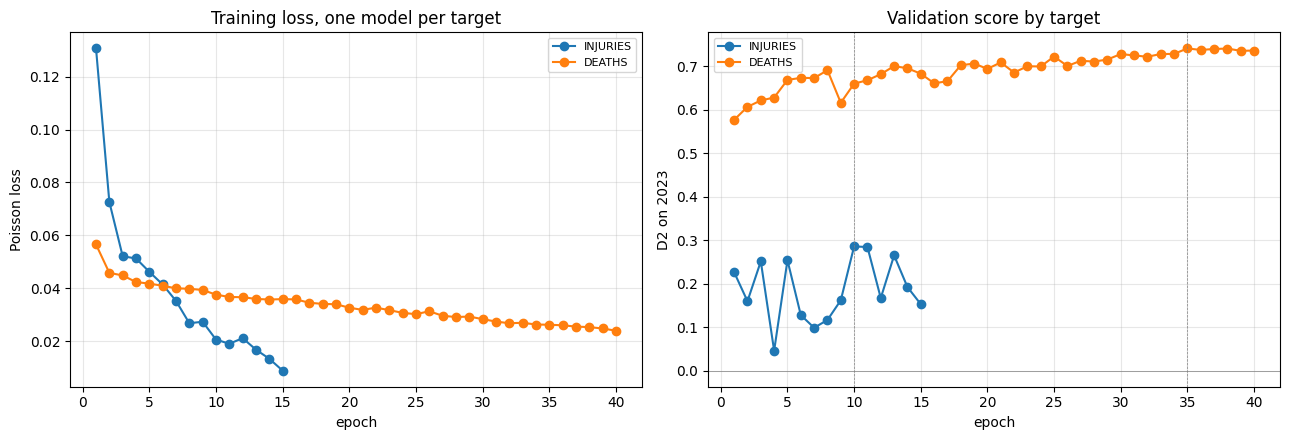

In [ ]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for target, result in results.items():
    history = result["history"]
    axes[0].plot(history["epoch"], history["loss"], marker="o", label=target)
    axes[1].plot(history["epoch"], history["val_D2"], marker="o", label=target)
    axes[1].axvline(result["best_epoch"], color="grey", linewidth=0.5, linestyle="--")

axes[0].set_xlabel("epoch")
axes[0].set_ylabel("Poisson loss")
axes[0].set_title("Training loss, one model per target")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("D2 on 2023")
axes[1].set_title("Validation score by target")
axes[1].axhline(0, color="grey", linewidth=0.5)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
figure.tight_layout()
plt.show()

In [ ]:
###########################################
# Adaptive Conformal Prediction
###########################################


def finite_sample_conformal_quantile(scores, alpha):
    """Computes the finite-sample-corrected (1-alpha)
    quantile of the calibration scores."""
    scores = np.sort(np.asarray(scores, dtype=float))
    rank = int(np.ceil((len(scores) + 1) * (1.0 - alpha)))

    if rank > len(scores):
        return np.inf

    return float(scores[rank - 1])


def adaptive_conformal_by_period(
    y_true,
    y_pred,
    dates,
    calibration_scores,
    alpha_target=0.10,
    gamma=0.01,
):
    """Adaptive conformal intervals updated once per temporal period."""
    actual = np.asarray(y_true, dtype=float)
    predicted = np.asarray(y_pred, dtype=float)
    period_dates = pd.DatetimeIndex(dates).normalize()

    lower = np.empty(len(actual))
    upper = np.empty(len(actual))
    covered = np.empty(len(actual), dtype=bool)
    alphas = np.empty(len(actual))

    alpha_t = alpha_target
    min_alpha = max(
        1e-3,
        1.0 / (len(calibration_scores) + 1),
    )

    for period in np.unique(period_dates):
        positions = np.flatnonzero(period_dates == period)

        alpha_t = float(np.clip(alpha_t, min_alpha, 0.999))
        q = finite_sample_conformal_quantile(calibration_scores, alpha_t)

        margin = q * np.sqrt(np.clip(predicted[positions], 1, None))
        lower[positions] = np.maximum(0.0, predicted[positions] - margin)
        upper[positions] = predicted[positions] + margin
        covered[positions] = (
            (actual[positions] >= lower[positions])
            & (actual[positions] <= upper[positions])
        )
        alphas[positions] = alpha_t

        alpha_t += gamma * (
            alpha_target - (1.0 - covered[positions].mean())
        )

    return lower, upper, upper - lower, covered, alphas


def _aggregate_split_predictions(
    predictions,
    split,
    freq,
    group_column=None,
    group_name=None,
):
    """Filters predictions to the given split and resamples
    the actual/predicted values by summing them at the given time."""
    split_mask = predictions["split"].eq(split)
    split_data = predictions.loc[
        split_mask,
        ["actual", "predicted"],
    ].copy()

    if group_name is not None:
        group_values = predictions.loc[split_mask, group_column]
        group_mask = group_values.eq(group_name).to_numpy()
        split_data.loc[~group_mask, ["actual", "predicted"]] = 0.0

    return split_data.resample(freq).sum()


def build_daily_base(predictions, group_column=None, group_name=None):
    """THE base measure: daily totals of actual and predicted, one row per
    calendar day, for the calibration and test splits."""
    return {
        split: _aggregate_split_predictions(
            predictions,
            split=split,
            freq="D",
            group_column=group_column,
            group_name=group_name,
        )
        for split in ("calibration", "test")
    }


CALIBRATION_WINDOW_DAYS = {"D": 1, "MS": 30}


def conformity_scores(daily_calibration, window_days):
    """Poisson-standardized absolute residuals of the daily base, summed over
    a rolling window as wide as the view will be read at.

    The window is what makes the monthly view usable."""
    frame = daily_calibration
    if window_days > 1:
        frame = frame.rolling(window_days).sum().dropna()

    return np.abs(
        frame["actual"].to_numpy() - frame["predicted"].to_numpy()
    ) / np.sqrt(np.clip(frame["predicted"].to_numpy(), 1, None))


def conformalize_base(
    daily_base,
    freq="D",
    alpha_target=0.10,
    gamma=0.01,
    calibration_window=None,
):
    """Adaptive conformal intervals on the daily base, re-aggregated to a
    monthly view."""
    calibration = daily_base["calibration"]
    test = daily_base["test"]

    if calibration_window is None:
        calibration_window = CALIBRATION_WINDOW_DAYS.get(freq, 1)

    calibration_scores = conformity_scores(calibration, calibration_window)

    if freq != "D":
        test = test.resample(freq).sum()

    lower, upper, width, covered, alphas = adaptive_conformal_by_period(
        y_true=test["actual"].to_numpy(),
        y_pred=test["predicted"].to_numpy(),
        dates=test.index,
        calibration_scores=calibration_scores,
        alpha_target=alpha_target,
        gamma=gamma,
    )

    return test.assign(
        lower=lower,
        upper=upper,
        width=width,
        covered=covered,
        alpha_t=alphas,
    )


def build_group_monthly_conformal(
    predictions,
    group_column=GROUP_COL,
    alpha_target=0.10,
    gamma=0.01,
    calibration_window=None,
):
    """One monthly conformal frame per event group, keyed by group name."""
    if group_column not in predictions.columns:
        return {}

    test_records = (
        predictions[predictions["split"].eq("test")]
        .groupby(group_column, observed=True)
        .size()
    )

    group_conformal = {}
    for group_name in predictions[group_column].dropna().unique():
        monthly = conformalize_base(
            build_daily_base(
                predictions,
                group_column=group_column,
                group_name=group_name,
            ),
            freq="MS",
            alpha_target=alpha_target,
            gamma=gamma,
            calibration_window=calibration_window,
        )
        monthly.attrs["test_records"] = int(test_records.get(group_name, 0))
        group_conformal[group_name] = monthly

    return group_conformal


### Predictions

In [ ]:
###################################
# One prediction per target
###################################

SPLIT_ORDER = ["train", "validation", "calibration", "test"]
MODEL_LABEL = "tabular-transformer"
POINT_METRIC_COLUMNS = ["n", "events", "D2", "RMSE", "MPD"]


def build_target_predictions(result, splits_raw, group_column=GROUP_COL):
    """One long frame per target: actual, predicted, split label and event group."""
    blocks = []
    for name in SPLIT_ORDER:
        frame = splits_raw[name]
        view = result["views"][name]
        block = pd.DataFrame(
            {"split": name,
             "actual": view["y"][:, 0].cpu().numpy(),
             "predicted": predict(result["params"], view)[:, 0]},
            index=frame.index)
        if group_column is not None and group_column in frame.columns:
            block[group_column] = frame[group_column].to_numpy()
        blocks.append(block)

    return pd.concat(blocks).sort_index(kind="stable")


def point_metrics(predictions):
    """n, events, D2, RMSE and MPD for one target, split by split."""
    rows = []
    for name in SPLIT_ORDER:
        part = predictions[predictions["split"].eq(name)]
        if len(part):
            rows.append({"split": name, **compute_metrics(part["actual"], part["predicted"])})

    return pd.DataFrame(rows).set_index("split")


def group_point_metrics(predictions, group_column=GROUP_COL):
    empty = pd.DataFrame(
        columns=POINT_METRIC_COLUMNS,
        index=pd.MultiIndex.from_arrays([[], []], names=["split", group_column]))

    if group_column not in predictions.columns:
        return empty

    rows = []
    for name in SPLIT_ORDER:
        part = predictions[predictions["split"].eq(name)]
        for group_name, block in part.groupby(group_column, observed=True):
            rows.append({"split": name, group_column: group_name,
                         **compute_metrics(block["actual"], block["predicted"])})

    return pd.DataFrame(rows).set_index(["split", group_column]) if rows else empty


def assemble_target_result(result, splits_raw, group_column=GROUP_COL,
                           alpha_target=0.10, gamma=0.01):
    predictions = build_target_predictions(result, splits_raw, group_column)
    daily_base = build_daily_base(predictions)

    return {
        **result,
        "model_name": MODEL_LABEL,
        "predictions": predictions,
        "metrics": point_metrics(predictions),
        "group_metrics": group_point_metrics(predictions, group_column),
        "daily_conformal": conformalize_base(daily_base, freq="D",
                                             alpha_target=alpha_target, gamma=gamma),
        "monthly_conformal": conformalize_base(daily_base, freq="MS",
                                               alpha_target=alpha_target, gamma=gamma),
        "group_monthly_conformal": build_group_monthly_conformal(
            predictions, group_column=group_column,
            alpha_target=alpha_target, gamma=gamma),
    }


def build_forecast_results(results, splits_raw, group_column=GROUP_COL,
                           alpha_target=0.10, gamma=0.01):
    forecast = {}

    for target, result in results.items():
        print(f"[{MODEL_LABEL}] scoring {target}...")
        forecast[target] = assemble_target_result(result, splits_raw, group_column,
                                                  alpha_target, gamma)

    return forecast

started = time.time()
forecast_results = build_forecast_results(results, splits_raw)
print(f"\nscoring wall time: {time.time() - started:.1f} s")


[tabular-transformer] scoring INJURIES...
[tabular-transformer] scoring DEATHS...

scoring wall time: 8.8 s


### Reporting

In [ ]:
#############################################################
# Reporting tables
#############################################################

def _order_splits(frame, column="Split"):
    """Train, validation, calibration, then test: the splits in the order they occur in time."""
    frame[column] = pd.Categorical(frame[column], categories=SPLIT_ORDER, ordered=True)
    return frame


def _select_targets(results, targets):
    """filter results per targets"""
    if targets is None:
        return results
    if isinstance(targets, str):
        targets = [targets]

    missing = [name for name in targets if name not in results]
    if missing:
        raise KeyError(f"{missing} not in results: available are {list(results)}")

    return {name: results[name] for name in targets}


def point_metrics_by_target(results, targets=None):
    """point metrics tables per outcome"""
    selected = _select_targets(results, targets)
    df = pd.concat({k: v["metrics"] for k, v in selected.items()})
    df.index.names = ["Target", "Split"]

    return _order_splits(df.reset_index()).set_index(["Target", "Split"]).sort_index()


def point_metrics_by_event_group(results, group_column=GROUP_COL, targets=None):
    """point metrics tables per outcome and event group"""
    frames = {
        k: v["group_metrics"]
        for k, v in _select_targets(results, targets).items()
        if v.get("group_metrics") is not None and not v["group_metrics"].empty
    }

    if not frames:
        index = pd.MultiIndex.from_arrays([[], [], []], names=["Target", "Split", group_column])
        return pd.DataFrame(columns=POINT_METRIC_COLUMNS, index=index)

    df = pd.concat(frames)
    df.index.names = ["Target", "Split", group_column]

    return _order_splits(df.reset_index()).set_index(["Target", "Split", group_column]).sort_index()


def event_monthly_conformal_summary(results, group_column=GROUP_COL):
    """Coverage per target and event group, read on the monthly view of the
    daily base."""
    rows = [
        {
            "Target": target,
            group_column: group_name,
            "Months": len(frame),
            "TestRecords": frame.attrs.get("test_records", 0),
            "Coverage": float(frame["covered"].mean()),
            "MeanActual": float(frame["actual"].mean()),
            "MeanWidth": float(frame["width"].mean()),
        }
        for target, result in results.items()
        for group_name, frame in result["group_monthly_conformal"].items()
    ]

    summary = pd.DataFrame(rows).set_index(["Target", group_column]).sort_index()

    return _add_relative_width(summary)


def _add_relative_width(summary):
    """Reads the band width against the level it is measuring.

    MeanWidth is in target units - deaths per month, injuries per day - so it
    cannot be compared across targets, views or event groups. RelWidth can:
    it is MeanWidth over MeanActual."""
    mean_actual = summary["MeanActual"]
    summary["RelWidth"] = summary["MeanWidth"] / mean_actual.where(mean_actual > 0)

    return summary


def daily_conformal_summary(results):
    """target coverage: it starts from daily results aggregated by target"""
    df = pd.concat({k: v["daily_conformal"] for k, v in results.items()})
    df.index.names = ["Target", "Date"]

    grouped = df.reset_index().groupby("Target")
    summary = pd.DataFrame({
        "Days": grouped["covered"].size(),
        "Coverage": grouped["covered"].mean(),
        "MeanActual": grouped["actual"].mean(),
        "MeanWidth": grouped["width"].mean(),
    })

    return _add_relative_width(summary)

In [ ]:
# ==============================================================================
# MONTHLY TOTAL: ACTUAL VS PREDICTED (FULL TIMELINE)
# ==============================================================================

TEST_YEAR = TEST_START.year

SHADED_SPLITS = {"validation": 0.12, "calibration": 0.20, "test": 0.30}


def plot_monthly_actual_vs_predicted(results, targets, freq="MS"):
    """Monthly totals, one panel per target side by side."""
    label = MODEL_LABEL

    fig, axes = plt.subplots(1, len(targets), figsize=(8 * len(targets), 5.5),
                             layout="constrained", squeeze=False)
    axes = axes.flatten()

    for idx, target in enumerate(targets):
        ax = axes[idx]
        predictions = results[target]["predictions"]
        monthly = predictions[["actual", "predicted"]].resample(freq).sum()

        for split_name, shade in SHADED_SPLITS.items():
            stamps = predictions.index[predictions["split"] == split_name]
            if len(stamps) == 0:
                continue
            ax.axvspan(
                stamps.min(),
                stamps.max(),
                color="grey",
                alpha=shade,
                linewidth=0,
                zorder=0,
            )

        ax.plot(
            monthly.index,
            monthly["predicted"],
            color="#e07b39",
            linewidth=2.0,
            label="predicted",
        )
        ax.plot(
            monthly.index,
            monthly["actual"],
            color="#1f4e79",
            linewidth=2.0,
            marker="o",
            markersize=3,
            label="actual",
        )

        ax.set_title(
            f"{target}: monthly view, actual vs {label}", fontsize=12
        )
        ax.set_xlabel("Month")
        ax.set_ylabel(f"{target.replace('_', ' ').capitalize()} per month")
        ax.legend(fontsize=10)

    plt.show()

In [ ]:
# ==============================================================================
# MONTHLY CONFORMAL PREDICTION INTERVALS
# ==============================================================================


def plot_conformal_monthly(results, targets, test_year=None):
    """Plot monthly adaptive conformal intervals."""
    label = MODEL_LABEL
    test_year = TEST_YEAR if test_year is None else test_year

    fig, axes = plt.subplots(
        1,
        len(targets),
        figsize=(8 * len(targets), 5.5),
        layout="constrained",
        squeeze=False,
    )
    axes = axes.flatten()

    for idx, target in enumerate(targets):
        ax = axes[idx]

        monthly = results[target]["monthly_conformal"]
        x = monthly.index

        ax.fill_between(
            x,
            monthly["lower"],
            monthly["upper"],
            color="#e07b39",
            alpha=0.20,
            label="90% conformal (adaptive)",
        )
        ax.plot(
            x,
            monthly["predicted"],
            color="#e07b39",
            linewidth=2.0,
            label="predicted",
        )
        ax.plot(
            x,
            monthly["actual"],
            color="#1f4e79",
            linewidth=2.0,
            marker="o",
            markersize=4,
            label="actual",
        )

        target_clean = target.replace("_", " ").capitalize()
        ax.set_title(
            f"{target_clean}, {test_year}: monthly adaptive conformal interval ({label})",
            fontsize=12,
        )
        ax.set_xlabel("Month")
        ax.set_ylabel(target_clean)
        ax.legend(fontsize=9, loc="upper left")

    plt.show()


def plot_conformal_monthly_by_event(
    results,
    target,
    test_year=None,
    event_groups=None,
    group_column=GROUP_COL,
    ncols=4,
):
    """Plot group-specific monthly conformal intervals for all event groups."""
    label = MODEL_LABEL
    test_year = TEST_YEAR if test_year is None else test_year
    group_conformal = results[target]["group_monthly_conformal"]

    group_counts = pd.Series(
        {
            name: frame.attrs.get("test_records", 0)
            for name, frame in group_conformal.items()
        },
        dtype=int,
    ).sort_values(ascending=False)

    if event_groups is not None:
        if isinstance(event_groups, str):
            event_groups = [event_groups]
        groups_to_plot = list(event_groups)
    else:
        groups_to_plot = group_counts.index.tolist()

    n_plots = len(groups_to_plot)
    cols = min(ncols, n_plots)
    rows = int(np.ceil(n_plots / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(5.0 * cols, 3.6 * rows),
        layout="constrained",
        squeeze=False,
    )
    axes = axes.flatten()

    target_clean = target.replace("_", " ").capitalize()
    legend_handles = None

    for idx, group_name in enumerate(groups_to_plot):
        ax = axes[idx]
        group_clean = str(group_name).replace("_", " ").capitalize()
        n_events = int(group_counts.get(group_name, 0))

        if n_events == 0:
            ax.set_title(f"{group_clean} - no test data", fontsize=10)
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        monthly = group_conformal[group_name]
        x = monthly.index

        ax.fill_between(
            x,
            monthly["lower"],
            monthly["upper"],
            color="#e07b39",
            alpha=0.20,
            label="90% conformal (adaptive)",
        )
        ax.plot(x, monthly["predicted"], color="#e07b39", linewidth=1.8,
                label="predicted")
        ax.plot(x, monthly["actual"], color="#1f4e79", linewidth=1.8,
                marker="o", markersize=3, label="actual")

        ax.set_title(f"{group_clean} (n test = {n_events})", fontsize=10)
        ax.tick_params(labelsize=8)
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

        if idx % cols == 0:
            ax.set_ylabel(f"Monthly {target_clean}", fontsize=9)
        if idx >= n_plots - cols:
            ax.set_xlabel("Month", fontsize=9)

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

    for idx in range(n_plots, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(
        f"{target_clean} - monthly conformal intervals by event, "
        f"{test_year} - {label}",
        fontsize=14,
    )
    if legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="outside lower center",
            ncols=3,
            fontsize=10,
        )
    plt.show()

In [ ]:
display(point_metrics_by_target(forecast_results).round(4))

n  events      D2    RMSE     MPD
Target   Split                                              
DEATHS   train        773121    9283  0.7330  0.7619  0.0569
         validation    39686     493  0.7411  0.8644  0.0942
         calibration   37371     510  0.5691  0.4466  0.1119
         test          38495     399  0.6852  0.3896  0.0646
INJURIES train        773121    6968  0.5472  3.9227  0.4051
         validation    39686     236  0.2857  4.7765  0.6780
         calibration   37371     231  0.2840  0.7033  0.2163
         test          38495     185  0.3556  1.0463  0.1778

In [ ]:
display(point_metrics_by_event_group(forecast_results, targets='INJURIES').round(4))

n  events      D2     RMSE     MPD
Target   Split       EVENT_GROUP                                              
INJURIES train       Avalanche           2761     199  0.2154   3.2470  1.1295
                     Coastal_Flood      22099     550  0.4475   0.6741  0.2644
                     Cold               45728     108  0.6463   0.2484  0.0446
                     Drought            68812       4  0.0060   1.3344  0.1139
                     Dust               17319     351  0.5574   1.5449  0.5718
                     Extreme_Heat       37596     814  0.5342   7.4166  2.0628
                     Flooding          159402     749  0.6721   3.7909  0.2799
                     High_Wind         145229    1134  0.3482   0.8361  0.1407
                     Tropical_Cyclone   11059     175  0.1736  24.0561  4.9454
                     Wildfire            8444     608  0.3004   2.2404  1.4962
                     Winter_Storm      254672    2276  0.5186   1.7591  0.2925
         validation  Avalanche            219      14  0.1971   0.3887  0.4360
                     Coastal_Flood        706      31  0.1954   0.5568  0.5208
                     Cold                1095       5  0.4569   0.3510  0.1356
                     Drought             5815       0     NaN   0.0013  0.0022
                     Dust                 530      11  0.3656   2.8825  1.3630
                     Extreme_Heat        8347      27  0.1787  10.3415  2.5857
                     Flooding            6474      13  0.0406   0.1025  0.0473
                     High_Wind           7288      34  0.3524   0.1351  0.0516
                     Tropical_Cyclone     338       5  0.1754   0.4060  0.2503
                     Wildfire             343      10 -0.2385   2.1403  2.1519
                     Winter_Storm        8531      86  0.2868   0.8475  0.2899
         calibration Avalanche            197      14  0.0276   0.3357  0.4574
                     Coastal_Flood        791      32  0.4015   0.4314  0.3078
                     Cold                1844       4 -0.1721   0.3967  0.2167
                     Drought             3473       0     NaN   0.0012  0.0021
                     Dust                 934      24  0.4469   1.8571  0.7473
                     Extreme_Heat        5831      27  0.1344   0.8782  0.4632
                     Flooding            7134      12 -0.1290   0.0794  0.0393
                     High_Wind           7564      40  0.4008   0.1101  0.0484
                     Tropical_Cyclone     813      13 -0.1064   2.7383  1.5085
                     Wildfire             336      13  0.3029   1.2974  0.9016
                     Winter_Storm        8454      52  0.2678   0.6440  0.2091
         test        Avalanche            197       8  0.1510   0.3467  0.2513
                     Coastal_Flood        612      30  0.1620   0.5794  0.5694
                     Cold                3083       3  0.3851   0.0431  0.0112
                     Drought             3283       0     NaN   0.0015  0.0023
                     Dust                 955      15  0.5120   1.4823  0.4490
                     Extreme_Heat        4303      12  0.2197   2.9796  0.9151
                     Flooding            7655      18  0.0990   0.0964  0.0414
                     High_Wind           7934      17  0.1483   0.0660  0.0281
                     Tropical_Cyclone      35       0     NaN   1.7814  0.9402
                     Wildfire             350      14  0.5789   0.5293  0.3655
                     Winter_Storm       10088      68  0.2618   0.3575  0.1327

In [ ]:
display(point_metrics_by_event_group(forecast_results, targets='DEATHS').round(4))

n  events      D2    RMSE     MPD
Target Split       EVENT_GROUP                                             
DEATHS train       Avalanche           2761     363  0.6995  0.5928  0.2826
                   Coastal_Flood      22099    1348  0.8354  0.2317  0.0684
                   Cold               45728     716  0.8480  0.1250  0.0276
                   Drought            68812       0     NaN  0.0002  0.0001
                   Dust               17319     208  0.6667  0.1727  0.0549
                   Extreme_Heat       37596    2149  0.8359  0.8030  0.1564
                   Flooding          159402    1649  0.4930  0.1959  0.0775
                   High_Wind         145229     687  0.6045  0.0973  0.0272
                   Tropical_Cyclone   11059     291  0.6897  6.0640  0.5493
                   Wildfire            8444     156  0.6212  0.6832  0.1748
                   Winter_Storm      254672    1716  0.5823  0.1090  0.0382
       validation  Avalanche            219      16  0.1398  0.5320  0.5584
                   Coastal_Flood        706      83  0.8547  0.2212  0.0818
                   Cold                1095      12  0.7971  0.1108  0.0288
                   Drought             5815       0     NaN  0.0000  0.0001
                   Dust                 530      10  0.4533  0.4784  0.2418
                   Extreme_Heat        8347     228  0.8371  1.5023  0.1613
                   Flooding            6474      57  0.3550  0.1457  0.0726
                   High_Wind           7288      38  0.3174  0.0789  0.0416
                   Tropical_Cyclone     338       6 -0.0164  0.1800  0.1716
                   Wildfire             343       4  0.1937  5.4899  2.8193
                   Winter_Storm        8531      39  0.4687  0.0795  0.0299
       calibration Avalanche            197      13 -0.0224  0.9804  0.9319
                   Coastal_Flood        791      68  0.8369  0.2052  0.0782
                   Cold                1844      38  0.4031  0.1929  0.1310
                   Drought             3473       0     NaN  0.0001  0.0001
                   Dust                 934      13  0.3861  0.1961  0.1218
                   Extreme_Heat        5831     174  0.7652  0.9957  0.1586
                   Flooding            7134      76  0.0955  0.3221  0.1910
                   High_Wind           7564      31  0.6040  0.0942  0.0243
                   Tropical_Cyclone     813      41  0.2157  0.6533  0.5939
                   Wildfire             336       8 -0.1051  0.2679  0.2494
                   Winter_Storm        8454      48  0.2700  0.1399  0.0643
       test        Avalanche            197      11  0.3525  0.2967  0.2540
                   Coastal_Flood        612      59  0.7925  0.1876  0.0973
                   Cold                3083      25  0.7306  0.0787  0.0229
                   Drought             3283       0     NaN  0.0000  0.0001
                   Dust                 955      11  0.6881  0.2763  0.0783
                   Extreme_Heat        4303     139  0.8660  0.3102  0.0586
                   Flooding            7655      78  0.5918  0.7553  0.1404
                   High_Wind           7934      19  0.5028  0.0534  0.0160
                   Tropical_Cyclone      35       0     NaN  0.0931  0.0565
                   Wildfire             350       8  0.4990  1.4941  0.7597
                   Winter_Storm       10088      49  0.3145  0.1116  0.0505

In [ ]:
display(daily_conformal_summary(forecast_results).round(4))

,Days,Coverage,MeanActual,MeanWidth,RelWidth
Target,,,,,
DEATHS,365,0.9205,2.0740,3.5619,1.7174
INJURIES,365,0.9178,2.1945,4.6216,2.1060


In [ ]:
display(event_monthly_conformal_summary(forecast_results).round(4))

Months  TestRecords  Coverage  MeanActual  \
Target   EVENT_GROUP                                                   
DEATHS   Avalanche             12          197    1.0000      1.0833   
         Coastal_Flood         12          612    0.9167      5.0833   
         Cold                  12         3083    0.9167      2.2500   
         Drought               12         3283    0.9167      0.0000   
         Dust                  12          955    0.8333      2.0833   
         Extreme_Heat          12         4303    0.9167     21.0833   
         Flooding              12         7655    0.9167     18.8333   
         High_Wind             12         7934    1.0000      1.7500   
         Tropical_Cyclone      12           35    1.0000      0.0000   
         Wildfire              12          350    0.9167      5.2500   
         Winter_Storm          12        10088    0.9167      5.6667   
INJURIES Avalanche             12          197    0.9167      0.7500   
         Coastal_Flood         12          612    0.9167      5.3333   
         Cold                  12         3083    0.7500      0.3333   
         Drought               12         3283    0.9167      0.0000   
         Dust                  12          955    1.0000      7.3333   
         Extreme_Heat          12         4303    0.8333     31.4167   
         Flooding              12         7655    0.9167      2.3333   
         High_Wind             12         7934    0.7500      1.7500   
         Tropical_Cyclone      12           35    0.9167      0.0000   
         Wildfire              12          350    1.0000      3.5833   
         Winter_Storm          12        10088    0.7500     13.9167   

                           MeanWidth  RelWidth  
Target   EVENT_GROUP                            
DEATHS   Avalanche            4.1453    3.8264  
         Coastal_Flood        6.3351    1.2462  
         Cold                 2.4556    1.0914  
         Drought              0.0287       NaN  
         Dust                 3.8058    1.8268  
         Extreme_Heat        16.2364    0.7701  
         Flooding            28.2329    1.4991  
         High_Wind            5.7245    3.2712  
         Tropical_Cyclone     3.4120       NaN  
         Wildfire             3.7527    0.7148  
         Winter_Storm         5.7781    1.0197  
INJURIES Avalanche            4.8534    6.4712  
         Coastal_Flood       11.5049    2.1572  
         Cold                 1.0187    3.0561  
         Drought              0.8330       NaN  
         Dust                38.2910    5.2215  
         Extreme_Heat        24.9749    0.7950  
         Flooding             8.6101    3.6900  
         High_Wind            5.7138    3.2650  
         Tropical_Cyclone     6.2045       NaN  
         Wildfire            10.7935    3.0121  
         Winter_Storm        15.5797    1.1195

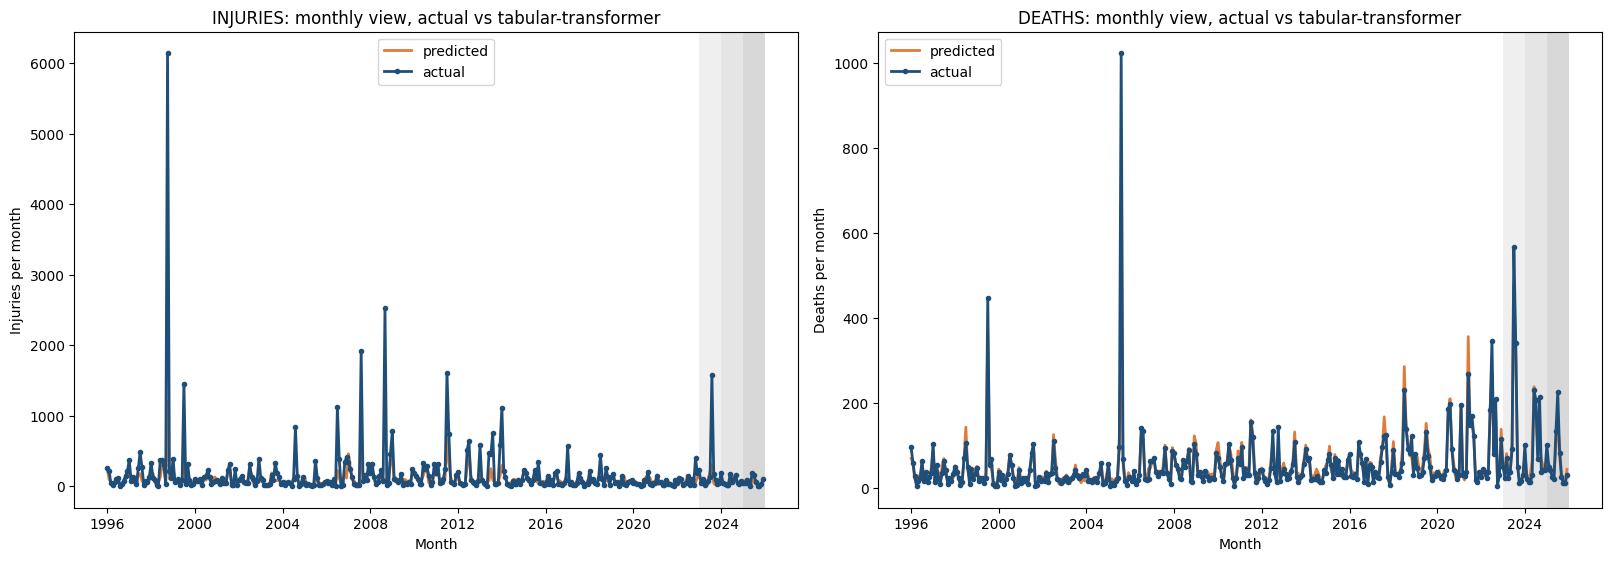

In [ ]:
target_list=PREDICTION_TARGETS
plot_monthly_actual_vs_predicted(forecast_results, target_list)

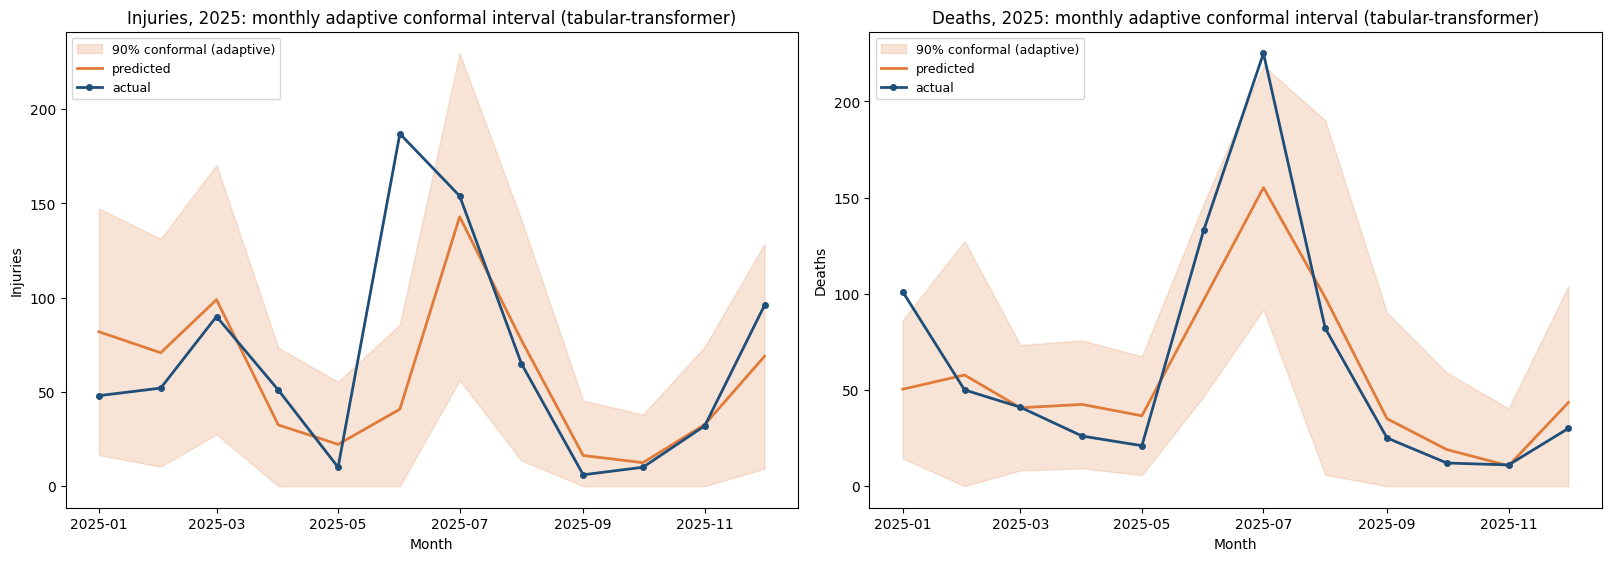

In [ ]:
plot_conformal_monthly(forecast_results, target_list, test_year=2025)

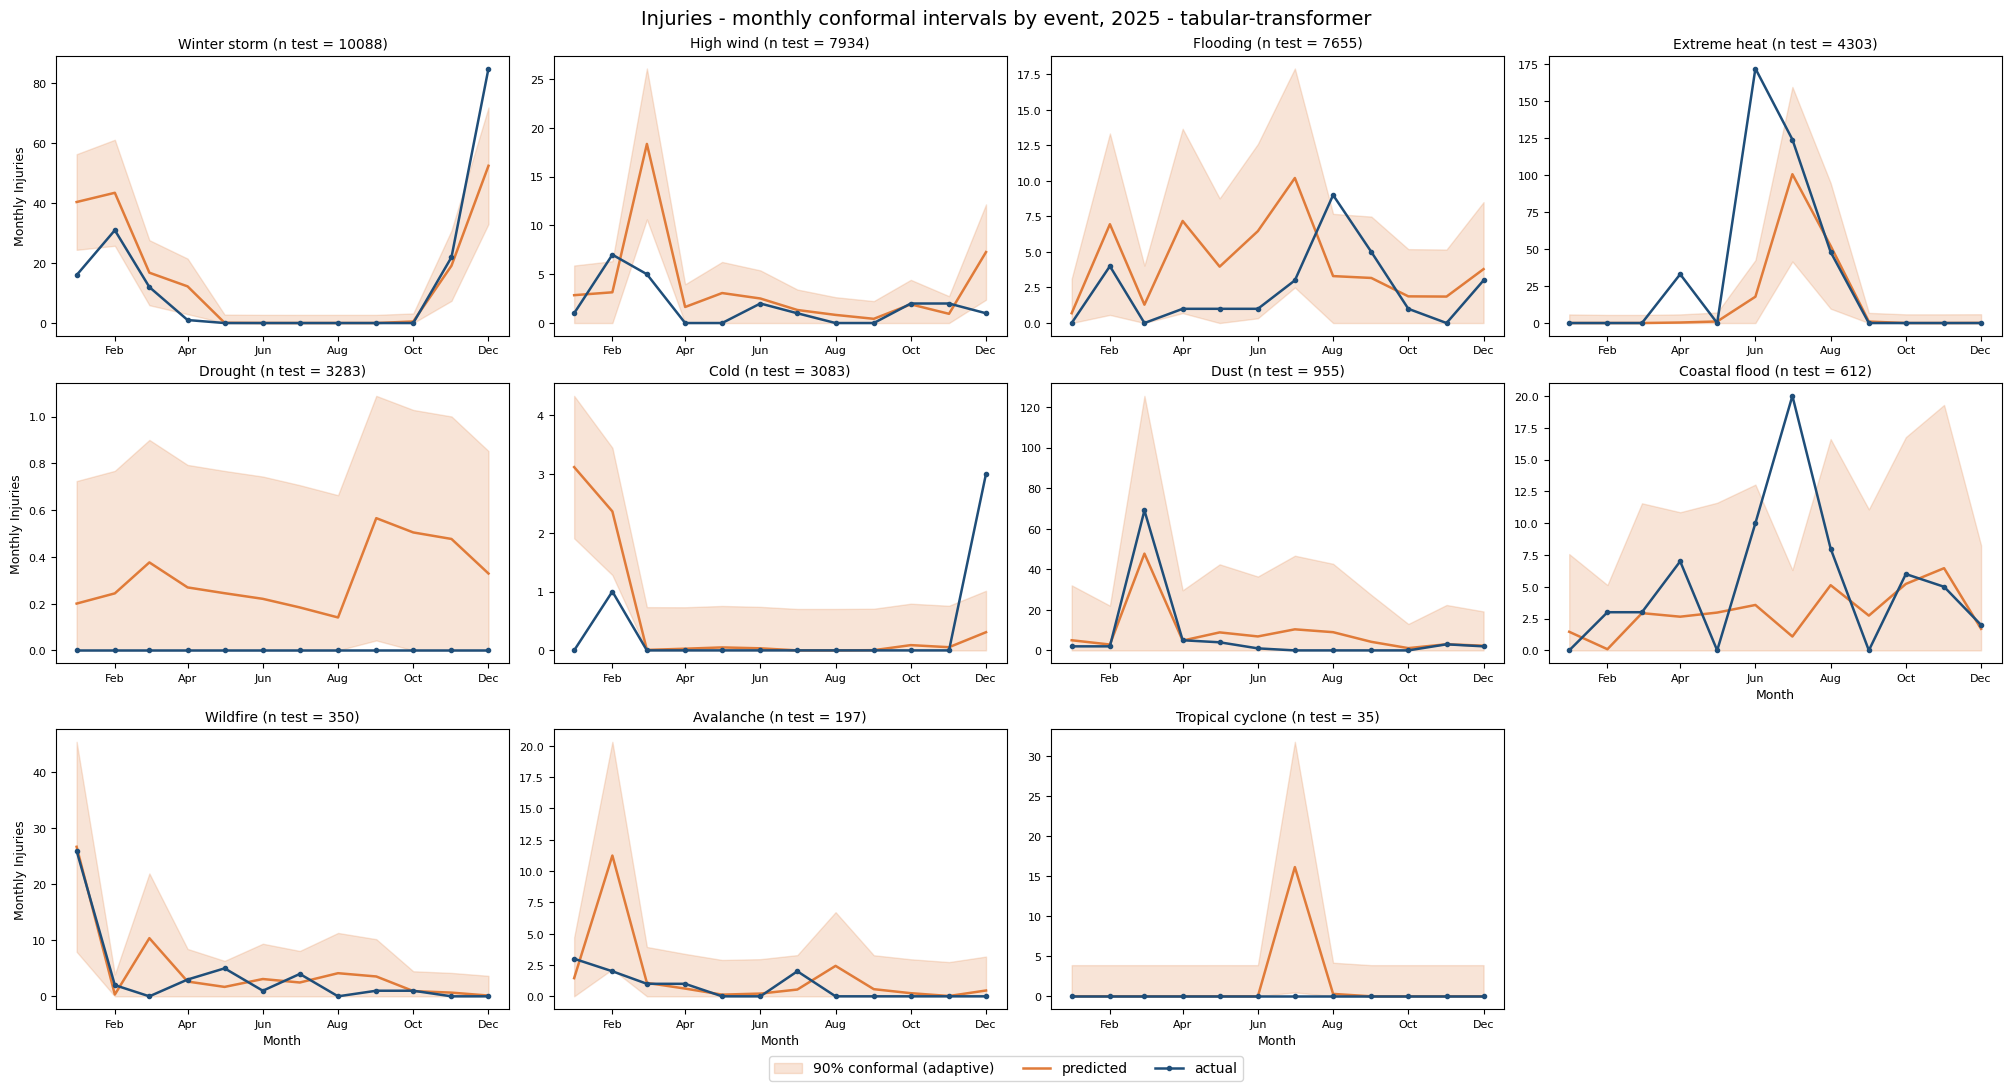

In [ ]:
plot_conformal_monthly_by_event(forecast_results, 'INJURIES', test_year=2025)

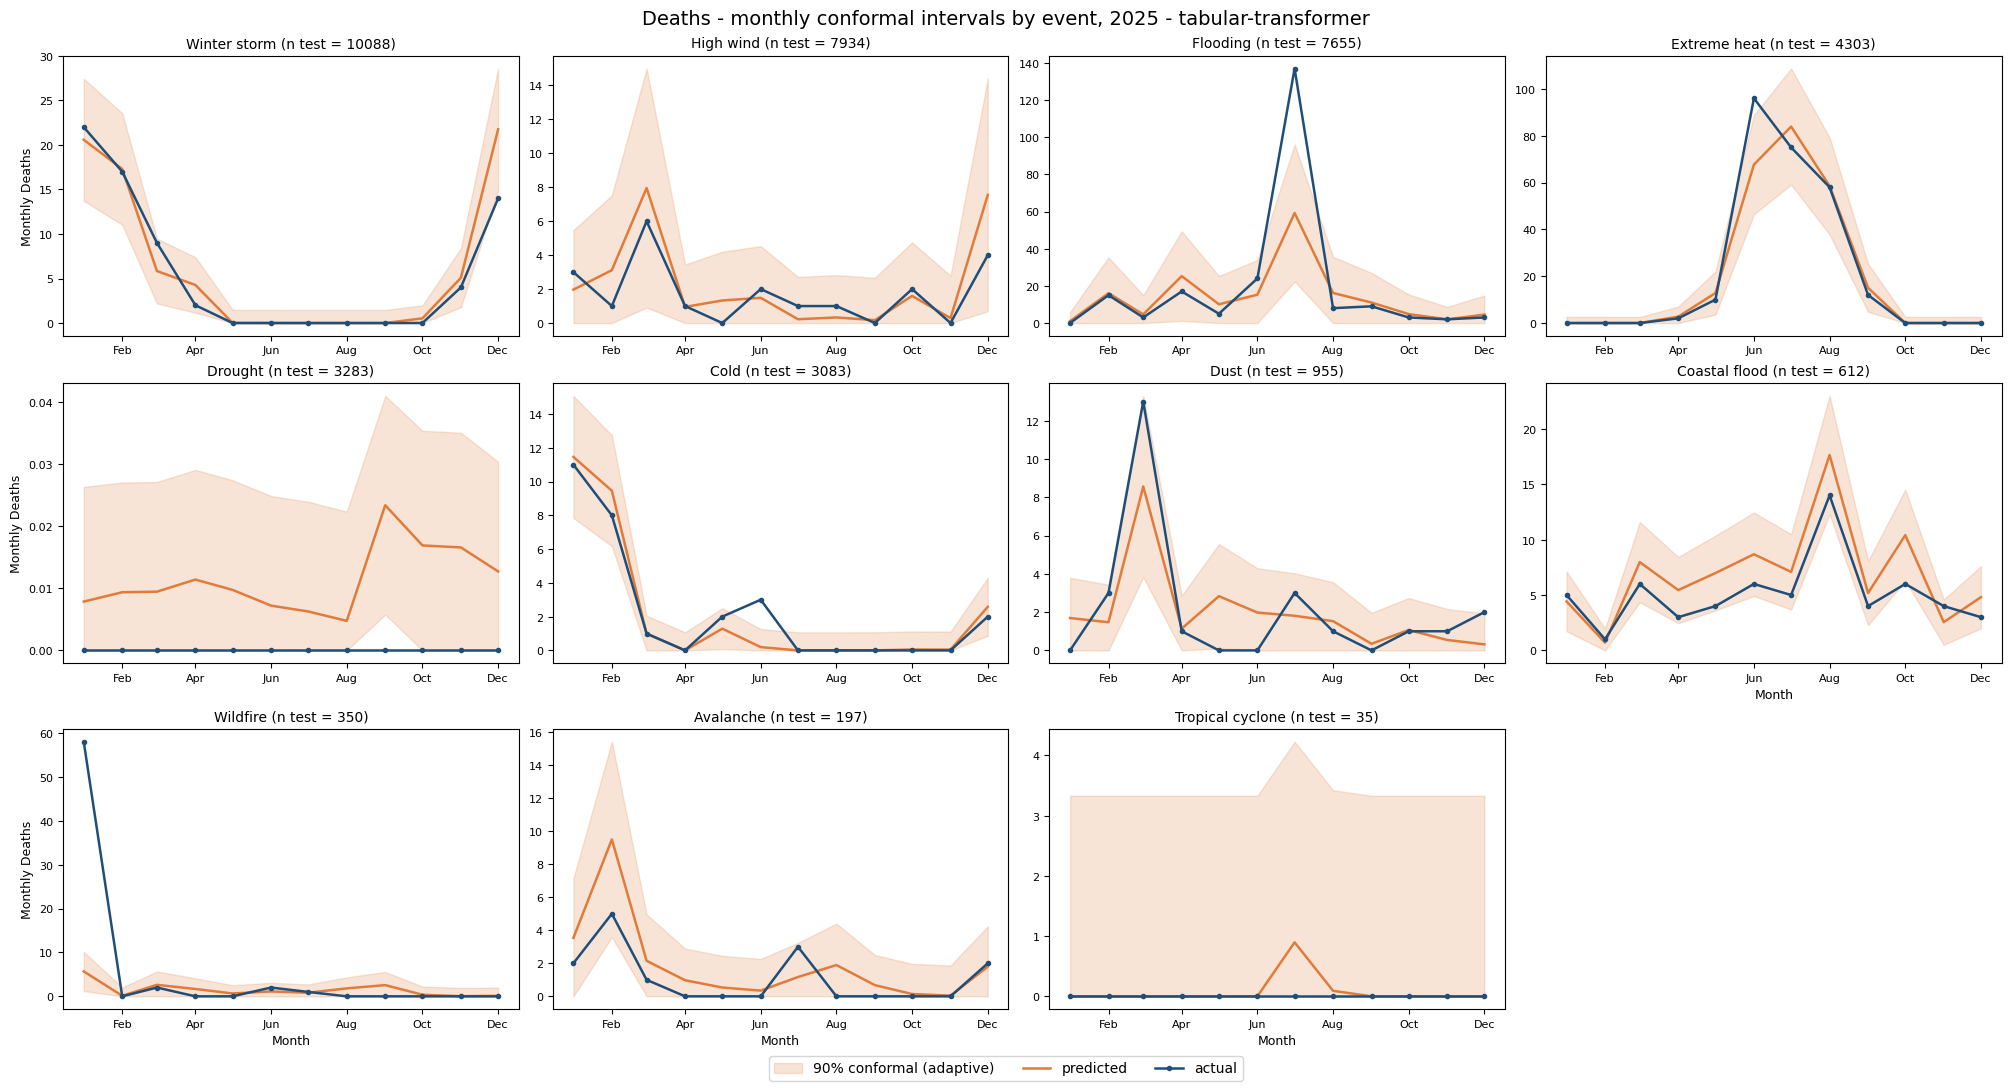

In [ ]:
plot_conformal_monthly_by_event(forecast_results, 'DEATHS', test_year=2025)

### Historical backtesting

In [ ]:
###################################################
# Historical backtesting
###################################################



BACKTEST_VALIDATION_YEARS = (2019, 2020, 2021, 2022, 2023)


def expanding_year_splits(frame, validation_years=BACKTEST_VALIDATION_YEARS):
    """Train on every year strictly before val_year, validate on val_year alone."""
    years = frame.index.year.to_numpy()
    for fold, val_year in enumerate(validation_years, start=1):
        yield (fold, val_year,
               np.flatnonzero(years < val_year),
               np.flatnonzero(years == val_year))


def backtest_target_cv(frame, config, target, epochs,
                       validation_years=BACKTEST_VALIDATION_YEARS):
    """backtesting end-to-end pipeline."""
    index = PREDICTION_TARGETS.index(target)
    records = []

    print("=" * 78)
    print(f"backtesting {target} at {epochs} epochs per fold")
    print("=" * 78)

    for fold, val_year, train_index, val_index in expanding_year_splits(frame, validation_years):
        fold_train = frame.iloc[train_index].copy()
        fold_validation = frame.iloc[val_index].copy()
        encoders = fit_encoders(fold_train)
        tensors = {"train": encode_split(fold_train, encoders),
                   "validation": encode_split(fold_validation, encoders)}
        cardinalities = [len(encoders["vocabularies"][column]) + 1 for column in CATEGORICAL]
        views = {name: target_view(part, index) for name, part in tensors.items()}

        print(f"fold {fold}: train <= {val_year - 1} ({len(fold_train):,} rows)   "
              f"validation = {val_year} ({len(fold_validation):,} rows)")

        baseline_rate = (views["train"]["y"].sum(dim=0)
                         / views["train"]["exposure"].sum()).clamp(min=1e-8)
        fold_params = make_params(config, cardinalities, baseline_rate)
        train_model(fold_params, views["train"], config, epochs=epochs)
        predicted = predict(fold_params, views["validation"])[:, 0]

        records.append(pd.DataFrame(
            {"fold": fold, "validation_year": val_year,
             "actual": views["validation"]["y"][:, 0].cpu().numpy(),
             "predicted": predicted},
            index=fold_validation.index))

        del fold_params, tensors, views, fold_train, fold_validation
        gc.collect()
        torch.cuda.empty_cache()

    return pd.concat(records).sort_index(kind="stable")

In [ ]:
started = time.time()
oof = {target: backtest_target_cv(train_events, MODEL_CONFIG, target, results[target]["best_epoch"])
       for target in PREDICTION_TARGETS}
if DEVICE.type == "cuda":
    torch.cuda.synchronize()
print(f"\nbacktest wall time: {(time.time() - started) / 60:.1f} min")


backtesting INJURIES at 10 epochs per fold
fold 1: train <= 2018 (627,316 rows)   validation = 2019 (36,353 rows)
  epoch   1  loss   0.13094
  epoch   2  loss   0.06482
  epoch   3  loss   0.03323
  epoch   4  loss   0.02059
  epoch   5  loss   0.01356
  epoch   6  loss   0.00786
  epoch   7  loss   0.00129
  epoch   8  loss  -0.01095
  epoch   9  loss  -0.00428
  epoch  10  loss  -0.01713
fold 2: train <= 2019 (663,669 rows)   validation = 2020 (31,055 rows)
  epoch   1  loss   0.13952
  epoch   2  loss   0.07907
  epoch   3  loss   0.06220
  epoch   4  loss   0.04906
  epoch   5  loss   0.04190
  epoch   6  loss   0.03946
  epoch   7  loss   0.02929
  epoch   8  loss   0.02210
  epoch   9  loss   0.00746
  epoch  10  loss   0.01636
fold 3: train <= 2020 (694,724 rows)   validation = 2021 (36,224 rows)
  epoch   1  loss   0.14095
  epoch   2  loss   0.08544
  epoch   3  loss   0.05904
  epoch   4  loss   0.04720
  epoch   5  loss   0.03672
  epoch   6  loss   0.03172
  epoch   7  los

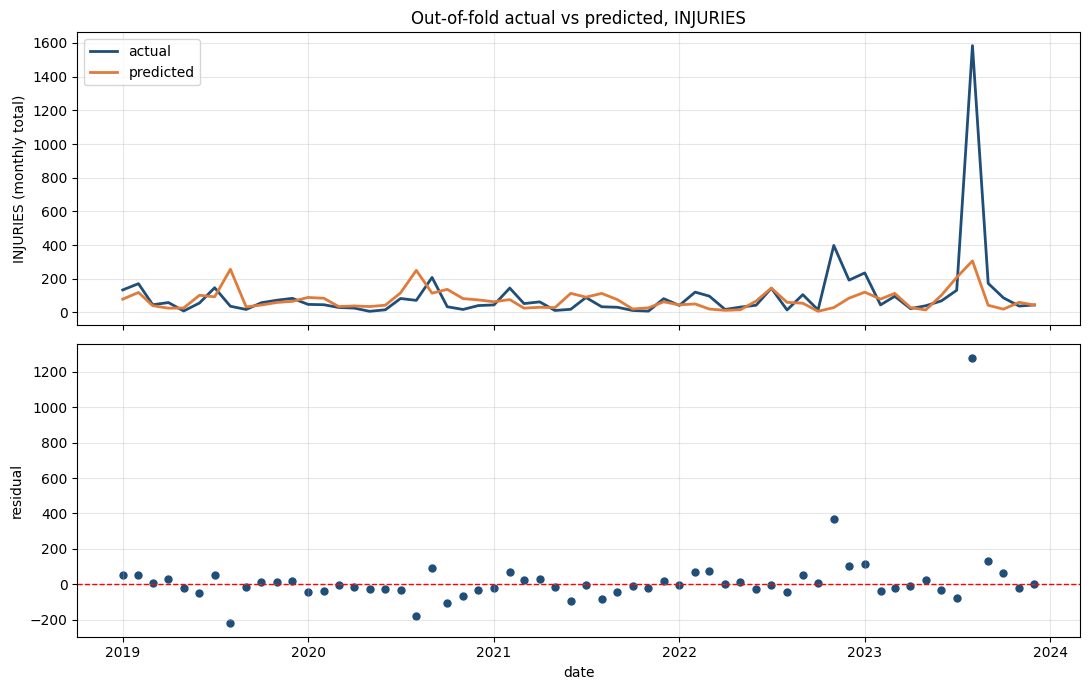

,n,events,D2,RMSE,MPD,ratio
year,,,,,,
2019,36353,184,0.4178,0.7452,0.1758,1.0602
2020,31055,177,0.3620,0.6933,0.1574,1.7522
2021,36224,161,0.3946,0.6568,0.1263,1.2340
2022,42173,235,0.0644,1.8160,0.3672,0.4864
2023,39686,236,0.2857,4.7765,0.6780,0.4449


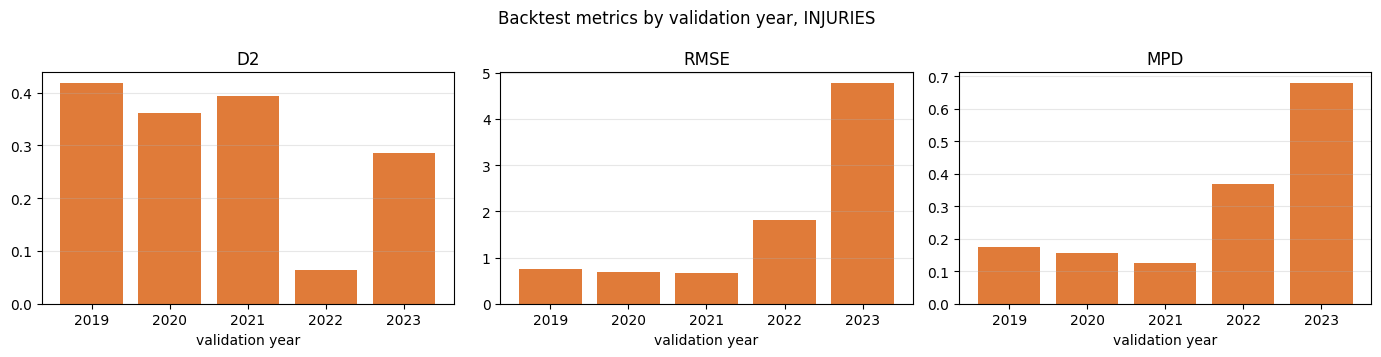

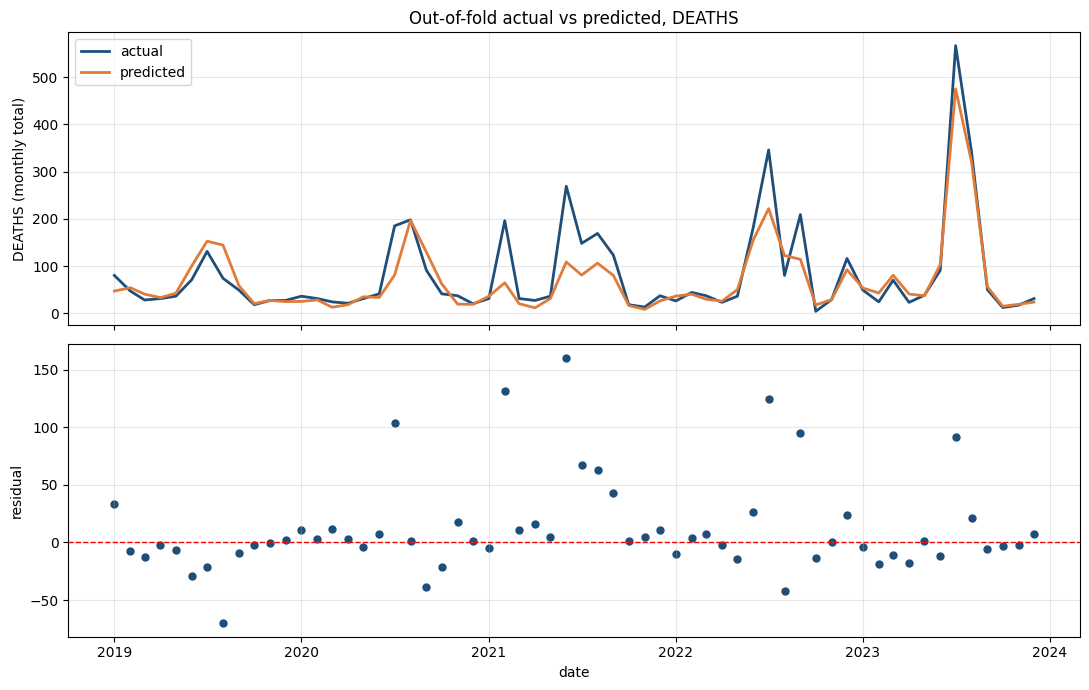

,n,events,D2,RMSE,MPD,ratio
year,,,,,,
2019,36353,467,0.6541,0.1601,0.0529,1.2022
2020,31055,385,0.5770,0.4539,0.1028,0.8717
2021,36224,548,0.6007,0.6136,0.1177,0.5365
2022,42173,496,0.6112,0.5006,0.1062,0.8242
2023,39686,493,0.7411,0.8644,0.0942,0.9638


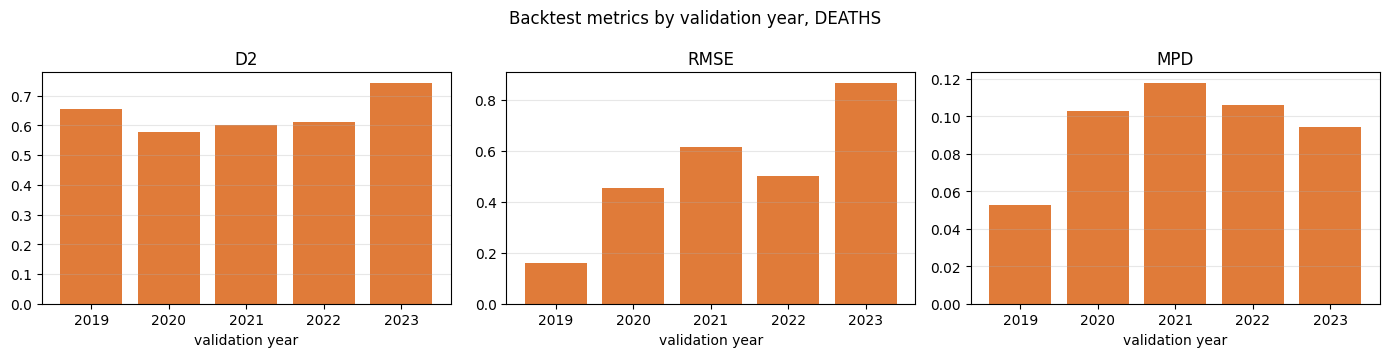

In [ ]:
def backtest_report(frame, target):
    """Monthly out-of-fold fit, residuals over time, and metrics by validation year."""
    monthly = frame[["actual", "predicted"]].resample("MS").sum()
    monthly["residual"] = monthly["actual"] - monthly["predicted"]

    figure, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    axes[0].plot(monthly.index, monthly["actual"], color="#1f4e79", linewidth=2, label="actual")
    axes[0].plot(monthly.index, monthly["predicted"], color="#e07b39", linewidth=2,
                 label="predicted")
    axes[0].set_ylabel(f"{target} (monthly total)")
    axes[0].set_title(f"Out-of-fold actual vs predicted, {target}")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[1].scatter(monthly.index, monthly["residual"], color="#1f4e79", s=25)
    axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
    axes[1].set_ylabel("residual")
    axes[1].set_xlabel("date")
    axes[1].grid(alpha=0.3)
    figure.tight_layout()
    plt.show()

    by_year = pd.DataFrame([
        {"year": year, **compute_metrics(block["actual"], block["predicted"]),
         "ratio": block["predicted"].sum() / block["actual"].sum()}
        for year, block in frame.groupby("validation_year")
    ]).set_index("year")
    display(by_year.round(4))

    figure, axes = plt.subplots(1, 3, figsize=(14, 3.6))
    for axis, metric in zip(axes, ["D2", "RMSE", "MPD"]):
        axis.bar(by_year.index.astype(str), by_year[metric], color="#e07b39")
        axis.set_title(metric)
        axis.set_xlabel("validation year")
        axis.grid(alpha=0.3, axis="y")
    figure.suptitle(f"Backtest metrics by validation year, {target}")
    figure.tight_layout()
    plt.show()
    return by_year


backtest_by_year = {target: backtest_report(frame, target) for target, frame in oof.items()}

In [ ]:
#############################################################
# EXPORT RESULTS FOR THE COMPARISON NOTEBOOK
#############################################################
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

RESULTS_DIR = Path("/content/drive/MyDrive/Storm_Events/global_model_results")
EXPORT_KEYS = ["metrics", "group_metrics", "daily_conformal", "monthly_conformal"]

def export_results(results, name, label, results_dir=RESULTS_DIR):
    """Writes the tables the comparison notebook reads, one file per model.

    Fitted estimators, encoders and scalers stay behind: the comparison does
    not use them, and Keras and TabPFN objects do not pickle reliably."""
    results_dir.mkdir(parents=True, exist_ok=True)
    pd.to_pickle(
        {
            "label": label,
            "results": {
                target: {key: result[key] for key in EXPORT_KEYS}
                for target, result in results.items()
            },
        },
        results_dir / f"{name}.pkl",
    )




Mounted at /content/drive


In [ ]:
export_results(forecast_results, "tabular-transformer", "tabular-transformer")